# 🛒 QVI Retail Analytics — Data Analytics Project

**Dataset:** QVI Transaction Data + Purchase Behaviour  
**Period:** July 2018 – June 2019  
**Scope:** Data Cleaning · EDA · Customer Analysis · Sales & Revenue Insights · Segment Deep-Dive

---

## 0. Setup & Imports

In [2]:
import subprocess, sys
for p in ['pandas','numpy','matplotlib','seaborn','openpyxl']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])
print('All packages ready ✓')

All packages ready ✓


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#E91E63']
sns.set_palette(PALETTE)
print('Imports successful ✓')

Imports successful ✓


---
## 1. Data Loading

In [4]:
txn = pd.read_excel('QVI_transaction_data.xlsx')
beh = pd.read_csv('QVI_purchase_behaviour.csv')

print(f'Transaction Data : {txn.shape[0]:,} rows × {txn.shape[1]} columns')
print(f'Behaviour Data   : {beh.shape[0]:,} rows × {beh.shape[1]} columns')
print()
print('--- Transaction Data Sample ---')
display(txn.head())
print('--- Behaviour Data Sample ---')
display(beh.head())

Transaction Data : 264,836 rows × 8 columns
Behaviour Data   : 72,637 rows × 3 columns

--- Transaction Data Sample ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


--- Behaviour Data Sample ---


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
# Data types and nulls
print('=== Transaction Data Info ===')
print(txn.dtypes)
print('\nMissing values:')
print(txn.isnull().sum())
print()
print('=== Behaviour Data Info ===')
print(beh.dtypes)
print('\nMissing values:')
print(beh.isnull().sum())

=== Transaction Data Info ===
DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

Missing values:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

=== Behaviour Data Info ===
LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

Missing values:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


---
## 2. Data Cleaning & Feature Engineering

In [6]:
# ── Fix date (Excel serial → proper datetime) ──────────────────────────────
txn['DATE'] = pd.to_datetime(txn['DATE'], unit='D', origin='1899-12-30')
print('Date range:', txn['DATE'].min().date(), '→', txn['DATE'].max().date())

# ── Extract BRAND from product name ────────────────────────────────────────
txn['BRAND'] = txn['PROD_NAME'].str.split().str[0].str.title()

# ── Extract PACK SIZE (grams) from product name ────────────────────────────
txn['PACK_SIZE'] = txn['PROD_NAME'].str.extract(r'(\d+)[Gg]$').astype(float)

# ── Derive unit price ──────────────────────────────────────────────────────
txn['UNIT_PRICE'] = (txn['TOT_SALES'] / txn['PROD_QTY']).round(2)

# ── Calendar features ──────────────────────────────────────────────────────
txn['YEAR']        = txn['DATE'].dt.year
txn['MONTH_NUM']   = txn['DATE'].dt.month
txn['MONTH_NAME']  = txn['DATE'].dt.strftime('%b')
txn['MONTH']       = txn['DATE'].dt.to_period('M')
txn['QUARTER']     = txn['DATE'].dt.quarter
txn['WEEK']        = txn['DATE'].dt.isocalendar().week.astype(int)
txn['DAY_OF_WEEK'] = txn['DATE'].dt.day_name()
txn['IS_WEEKEND']  = txn['DAY_OF_WEEK'].isin(['Saturday','Sunday'])

print('\nNew columns added:', ['BRAND','PACK_SIZE','UNIT_PRICE','MONTH','QUARTER','WEEK','DAY_OF_WEEK','IS_WEEKEND'])

Date range: 2018-07-01 → 2019-06-30

New columns added: ['BRAND', 'PACK_SIZE', 'UNIT_PRICE', 'MONTH', 'QUARTER', 'WEEK', 'DAY_OF_WEEK', 'IS_WEEKEND']


In [7]:
# ── Merge datasets ─────────────────────────────────────────────────────────
df = txn.merge(beh, on='LYLTY_CARD_NBR', how='left')
print(f'Merged shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Identify & remove outliers ─────────────────────────────────────────────
print(f'\nRows with PROD_QTY > 100: {(df["PROD_QTY"] > 100).sum()}')
print('These are bulk/non-retail orders — removing them.')
df = df[df['PROD_QTY'] <= 100].reset_index(drop=True)
print(f'Clean dataset: {df.shape[0]:,} rows')

Merged shape: 264,836 rows × 21 columns

Rows with PROD_QTY > 100: 2
These are bulk/non-retail orders — removing them.
Clean dataset: 264,834 rows


In [8]:
# ── Summary statistics ─────────────────────────────────────────────────────
print('=== Key Business Metrics ===')
print(f'Total Revenue        : ${df["TOT_SALES"].sum():,.0f}')
print(f'Total Transactions   : {df["TXN_ID"].nunique():,}')
print(f'Unique Customers     : {df["LYLTY_CARD_NBR"].nunique():,}')
print(f'Unique Stores        : {df["STORE_NBR"].nunique()}')
print(f'Unique Products      : {df["PROD_NBR"].nunique()}')
print(f'Unique Brands        : {df["BRAND"].nunique()}')
print(f'Avg Transaction Value: ${df["TOT_SALES"].mean():.2f}')
print(f'Avg Units per Txn    : {df["PROD_QTY"].mean():.2f}')

=== Key Business Metrics ===
Total Revenue        : $1,933,115
Total Transactions   : 263,125
Unique Customers     : 72,636
Unique Stores        : 272
Unique Products      : 114
Unique Brands        : 29
Avg Transaction Value: $7.30
Avg Units per Txn    : 1.91


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Key Variables

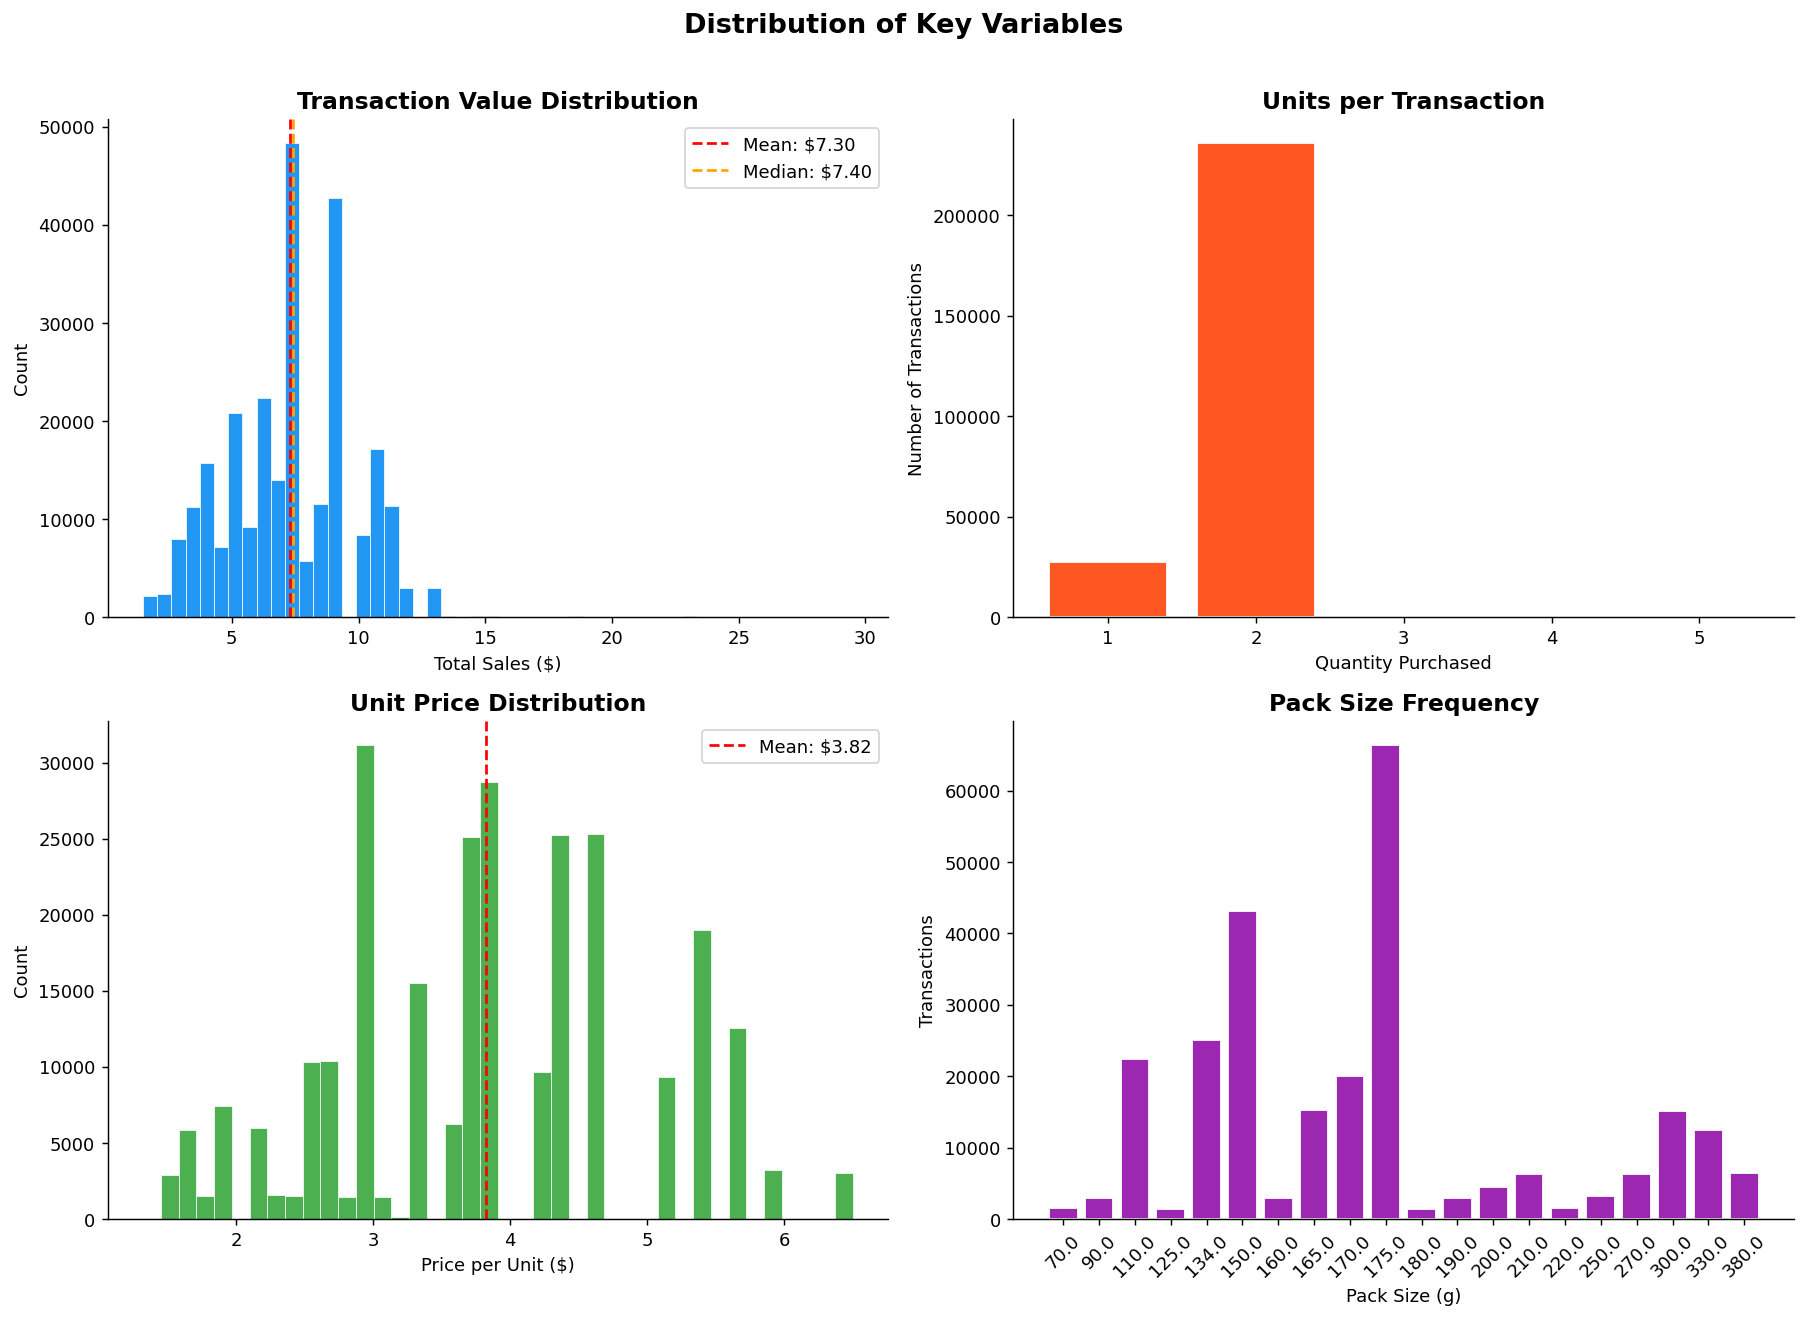

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Sales
axes[0,0].hist(df['TOT_SALES'], bins=50, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0,0].axvline(df['TOT_SALES'].mean(), color='red', linestyle='--', label=f'Mean: ${df["TOT_SALES"].mean():.2f}')
axes[0,0].axvline(df['TOT_SALES'].median(), color='orange', linestyle='--', label=f'Median: ${df["TOT_SALES"].median():.2f}')
axes[0,0].set_title('Transaction Value Distribution')
axes[0,0].set_xlabel('Total Sales ($)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Product Quantity
qty_counts = df['PROD_QTY'].value_counts().sort_index().head(10)
axes[0,1].bar(qty_counts.index.astype(str), qty_counts.values, color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('Units per Transaction')
axes[0,1].set_xlabel('Quantity Purchased')
axes[0,1].set_ylabel('Number of Transactions')

# Unit Price
axes[1,0].hist(df['UNIT_PRICE'].dropna(), bins=40, color=PALETTE[2], edgecolor='white', linewidth=0.4)
axes[1,0].axvline(df['UNIT_PRICE'].mean(), color='red', linestyle='--', label=f'Mean: ${df["UNIT_PRICE"].mean():.2f}')
axes[1,0].set_title('Unit Price Distribution')
axes[1,0].set_xlabel('Price per Unit ($)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Pack Size
pack_counts = df['PACK_SIZE'].value_counts().sort_index().dropna()
axes[1,1].bar(pack_counts.index.astype(str), pack_counts.values, color=PALETTE[3], edgecolor='white')
axes[1,1].set_title('Pack Size Frequency')
axes[1,1].set_xlabel('Pack Size (g)')
axes[1,1].set_ylabel('Transactions')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Key Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Missing Values & Data Quality

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
quality = quality[quality['Missing Count'] > 0]

if quality.empty:
    print('✅ No missing values found in the merged dataset!')
else:
    print('⚠️  Missing values detected:')
    display(quality)

# Duplicate check
dupes = df.duplicated(subset='TXN_ID').sum()
print(f'\n✅ Duplicate transaction IDs: {dupes}')
print(f'✅ Date range: {df["DATE"].min().date()} → {df["DATE"].max().date()} ({df["DATE"].nunique()} unique dates)')

⚠️  Missing values detected:


,Missing Count,Missing %
PACK_SIZE,3257,1.23



✅ Duplicate transaction IDs: 1709
✅ Date range: 2018-07-01 → 2019-06-30 (364 unique dates)


---
## 4. Sales & Revenue Analysis

### 4.1 Monthly Revenue & Transaction Trend

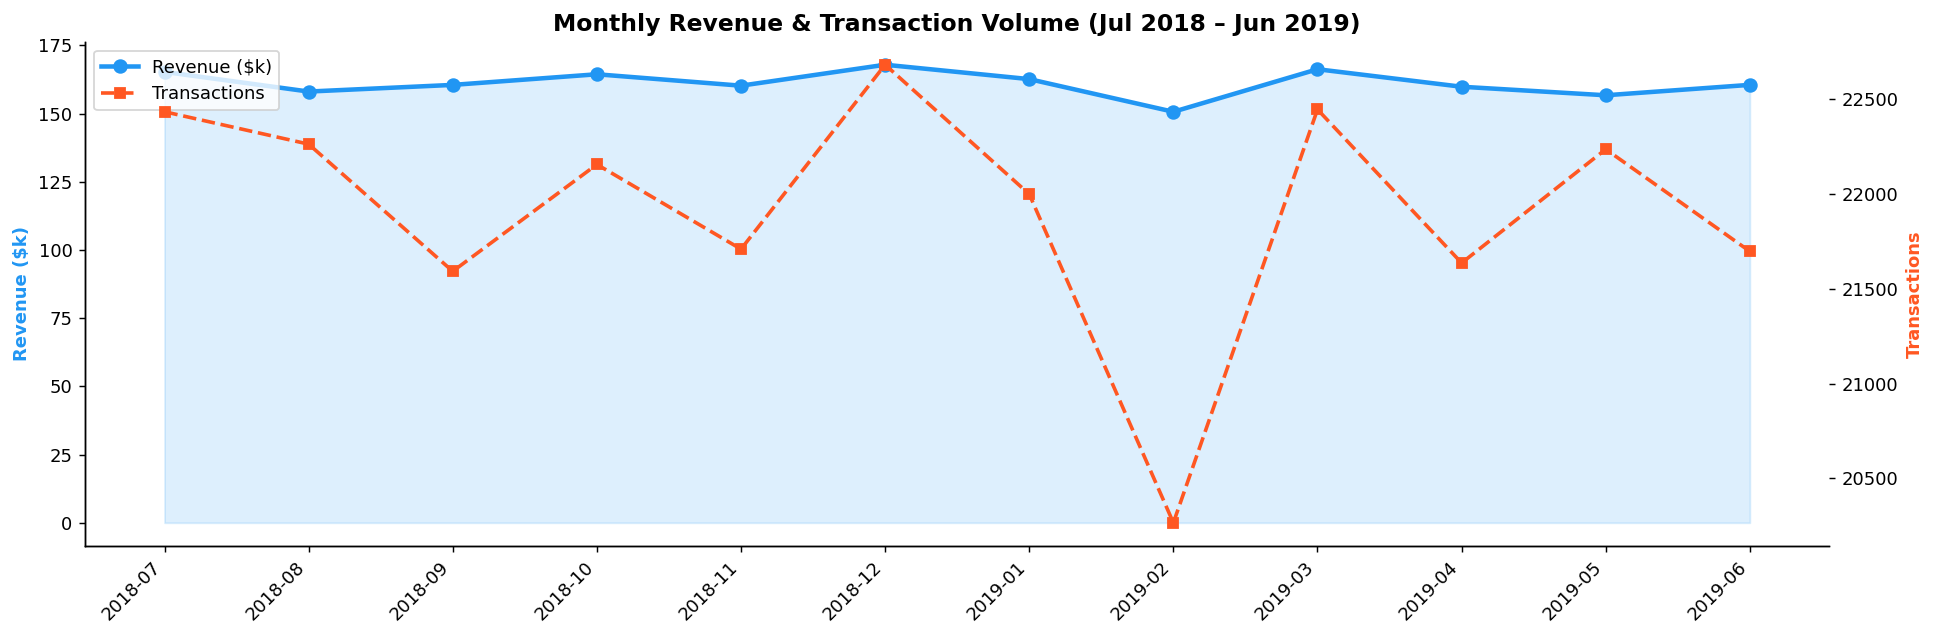

📈 Peak month  : 2018-12 — $167,913
📉 Lowest month: 2019-02  — $150,665
📊 Revenue variance: $4,711 std dev


In [11]:
monthly = df.groupby('MONTH').agg(
    Revenue      =('TOT_SALES',      'sum'),
    Transactions =('TXN_ID',         'nunique'),
    Customers    =('LYLTY_CARD_NBR', 'nunique'),
    Avg_Basket   =('TOT_SALES',      'mean')
).reset_index()
monthly['MONTH_STR'] = monthly['MONTH'].astype(str)

fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

ax1.fill_between(range(len(monthly)), monthly['Revenue']/1000, alpha=0.15, color=PALETTE[0])
ax1.plot(range(len(monthly)), monthly['Revenue']/1000, marker='o', color=PALETTE[0], linewidth=2.5, markersize=7, label='Revenue ($k)')
ax2.plot(range(len(monthly)), monthly['Transactions'], marker='s', color=PALETTE[1], linewidth=2, linestyle='--', markersize=6, label='Transactions')

ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['MONTH_STR'], rotation=45, ha='right')
ax1.set_ylabel('Revenue ($k)', color=PALETTE[0], fontweight='bold')
ax2.set_ylabel('Transactions', color=PALETTE[1], fontweight='bold')
ax1.set_title('Monthly Revenue & Transaction Volume (Jul 2018 – Jun 2019)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

peak = monthly.loc[monthly['Revenue'].idxmax()]
low  = monthly.loc[monthly['Revenue'].idxmin()]
print(f'📈 Peak month  : {peak["MONTH_STR"]} — ${peak["Revenue"]:,.0f}')
print(f'📉 Lowest month: {low["MONTH_STR"]}  — ${low["Revenue"]:,.0f}')
print(f'📊 Revenue variance: ${monthly["Revenue"].std():,.0f} std dev')

### 4.2 Quarterly Performance

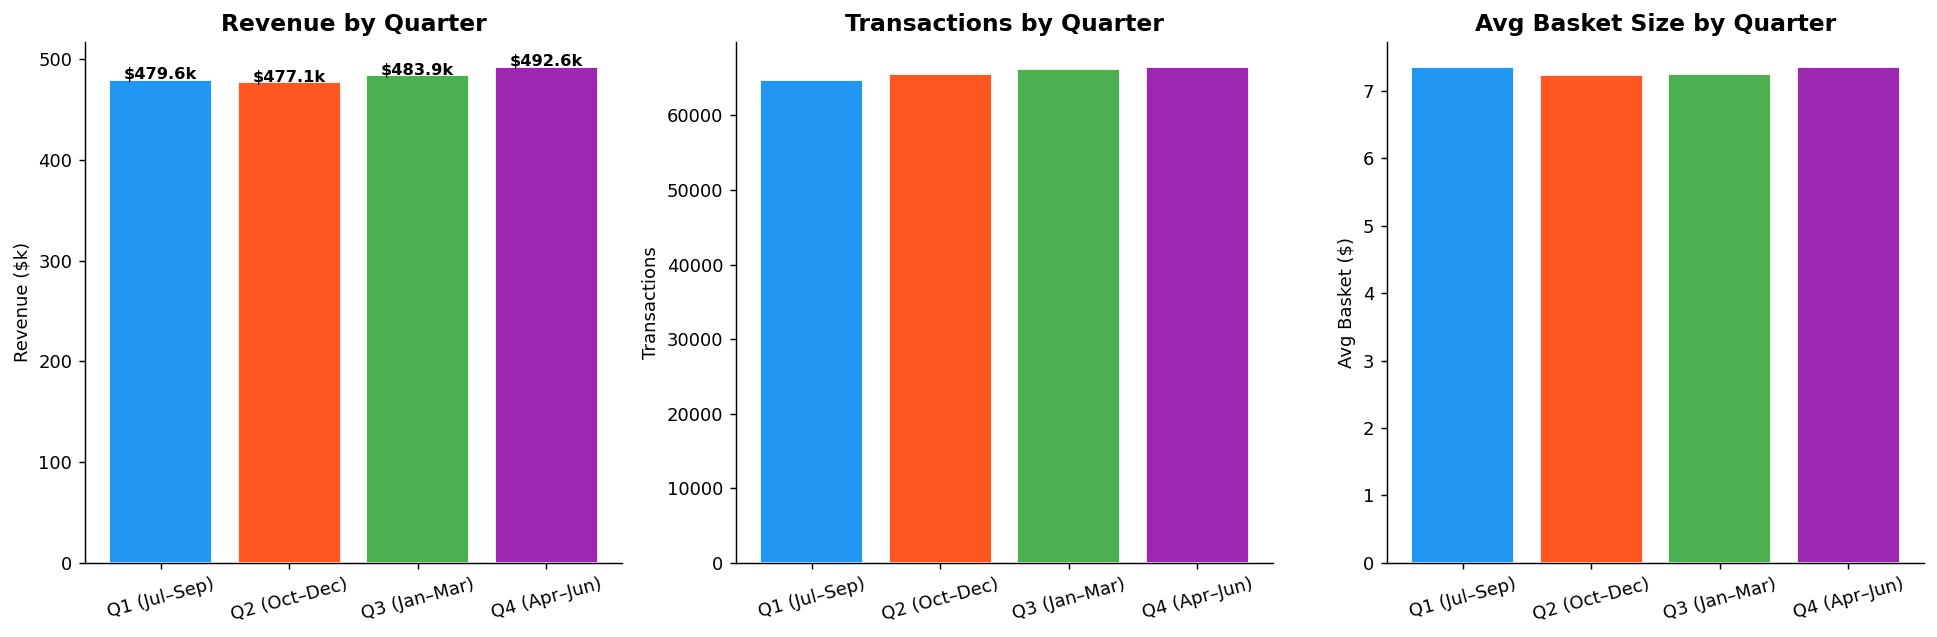

In [12]:
quarterly = df.groupby('QUARTER').agg(
    Revenue      =('TOT_SALES',      'sum'),
    Transactions =('TXN_ID',         'nunique'),
    Customers    =('LYLTY_CARD_NBR', 'nunique'),
    Avg_Basket   =('TOT_SALES',      'mean')
).reset_index()
quarterly['QUARTER_LABEL'] = quarterly['QUARTER'].map({1:'Q1 (Jul–Sep)',2:'Q2 (Oct–Dec)',3:'Q3 (Jan–Mar)',4:'Q4 (Apr–Jun)'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bars = axes[0].bar(quarterly['QUARTER_LABEL'], quarterly['Revenue']/1000, color=PALETTE[:4], edgecolor='white')
axes[0].set_title('Revenue by Quarter')
axes[0].set_ylabel('Revenue ($k)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, quarterly['Revenue']/1000):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${val:.1f}k', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(quarterly['QUARTER_LABEL'], quarterly['Transactions'], color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Transactions by Quarter')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(quarterly['QUARTER_LABEL'], quarterly['Avg_Basket'], color=PALETTE[:4], edgecolor='white')
axes[2].set_title('Avg Basket Size by Quarter')
axes[2].set_ylabel('Avg Basket ($)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 4.3 Day-of-Week & Weekend vs Weekday

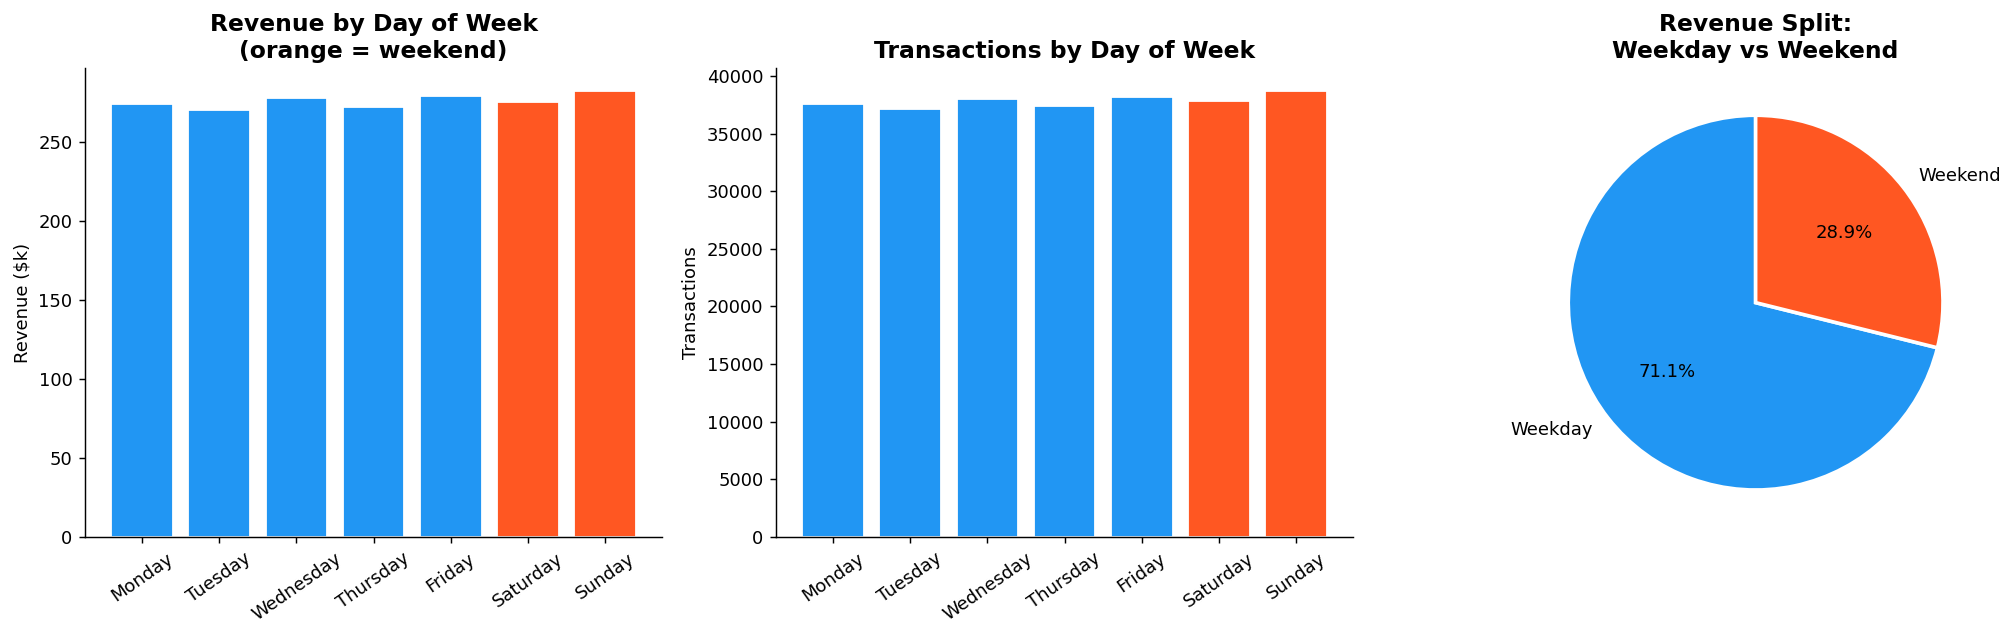

Weekday avg basket: $7.30
Weekend avg basket: $7.29


In [13]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DAY_OF_WEEK').agg(
    Revenue =('TOT_SALES','sum'),
    Txns    =('TXN_ID','count'),
    Avg     =('TOT_SALES','mean')
).reindex(dow_order)

weekend_rev = df.groupby('IS_WEEKEND')['TOT_SALES'].sum()
weekend_txn = df.groupby('IS_WEEKEND')['TXN_ID'].count()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_dow = [PALETTE[1] if d in ['Saturday','Sunday'] else PALETTE[0] for d in dow_order]
axes[0].bar(dow.index, dow['Revenue']/1000, color=colors_dow, edgecolor='white')
axes[0].set_title('Revenue by Day of Week\n(orange = weekend)')
axes[0].set_ylabel('Revenue ($k)')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(dow.index, dow['Txns'], color=colors_dow, edgecolor='white')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=35)

labels = ['Weekday','Weekend']
axes[2].pie(weekend_rev.values, labels=labels, autopct='%1.1f%%',
            colors=[PALETTE[0], PALETTE[1]], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('Revenue Split:\nWeekday vs Weekend')

plt.tight_layout()
plt.show()

print(f'Weekday avg basket: ${df[df["IS_WEEKEND"]==False]["TOT_SALES"].mean():.2f}')
print(f'Weekend avg basket: ${df[df["IS_WEEKEND"]==True]["TOT_SALES"].mean():.2f}')

---
## 5. Product Analysis

### 5.1 Top Brands by Revenue, Volume & Price

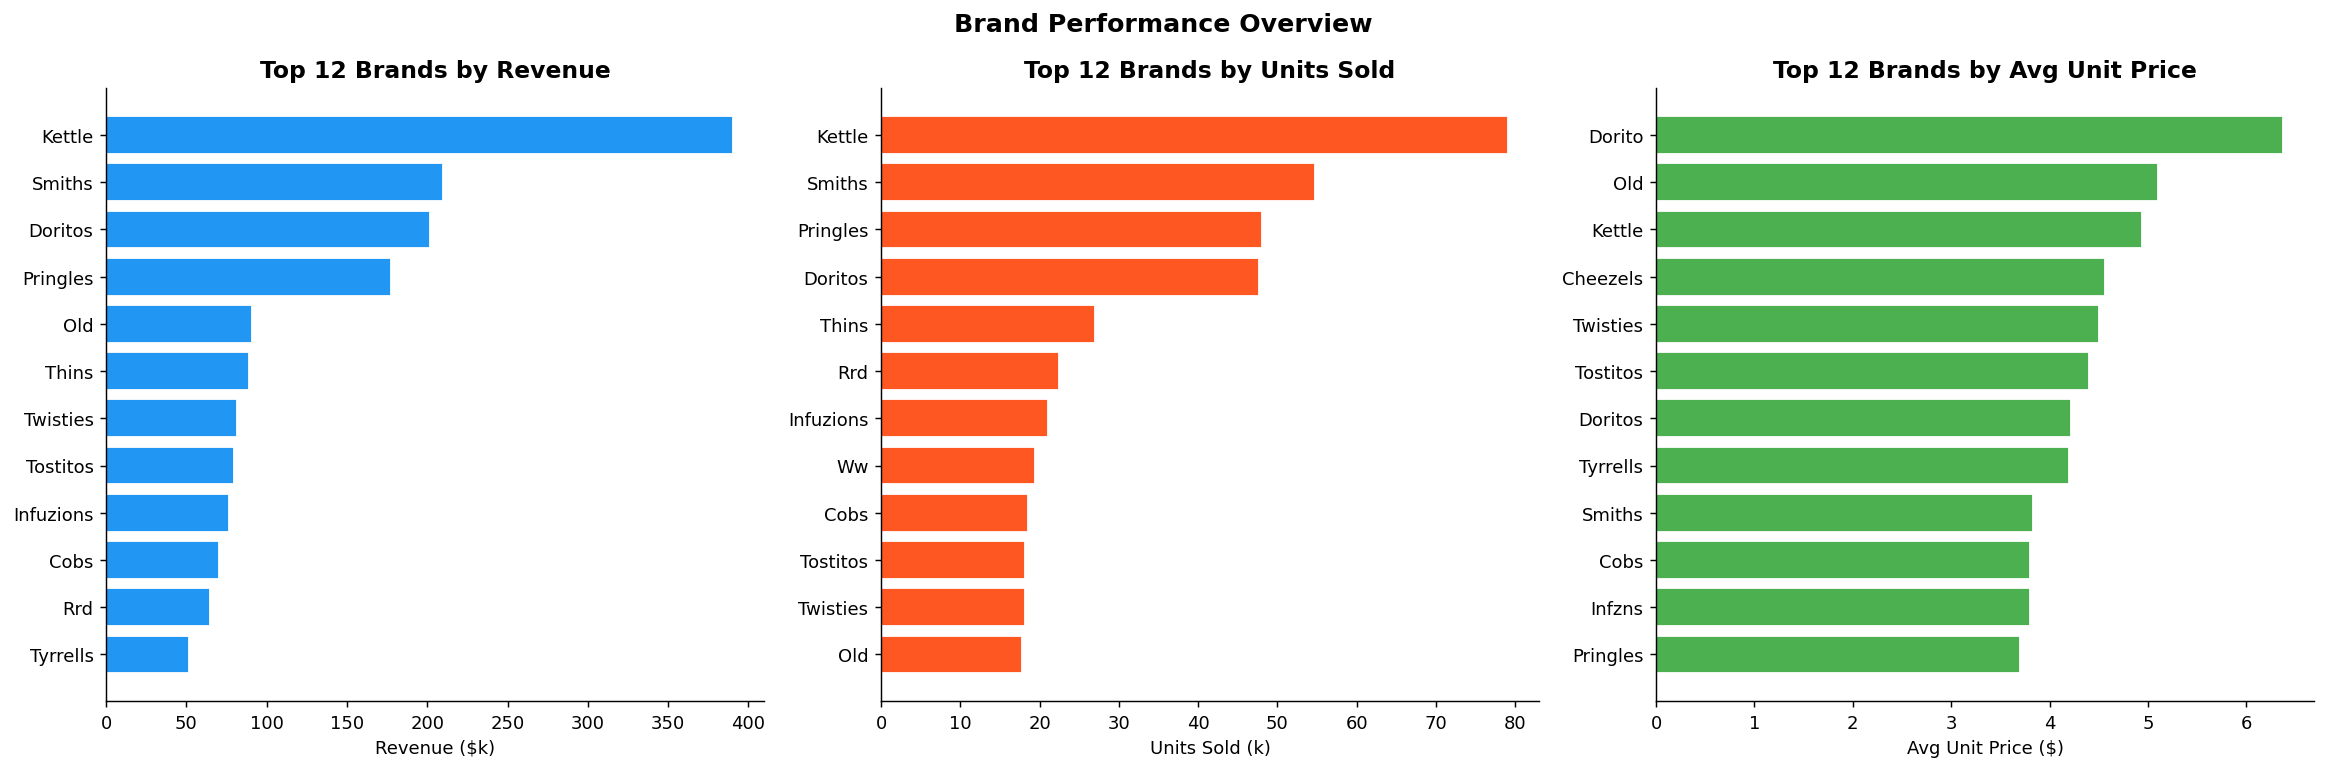

In [14]:
brand = df.groupby('BRAND').agg(
    Revenue   =('TOT_SALES',  'sum'),
    Units_Sold=('PROD_QTY',   'sum'),
    Avg_Price =('UNIT_PRICE', 'mean'),
    Txns      =('TXN_ID',     'count')
).reset_index().sort_values('Revenue', ascending=False)

top12 = brand.head(12)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue
axes[0].barh(top12['BRAND'][::-1], top12['Revenue'][::-1]/1000, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Top 12 Brands by Revenue')
axes[0].set_xlabel('Revenue ($k)')

# Units sold
top12_vol = brand.sort_values('Units_Sold', ascending=False).head(12)
axes[1].barh(top12_vol['BRAND'][::-1], top12_vol['Units_Sold'][::-1]/1000, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Top 12 Brands by Units Sold')
axes[1].set_xlabel('Units Sold (k)')

# Avg price
top12_price = brand.sort_values('Avg_Price', ascending=False).head(12)
axes[2].barh(top12_price['BRAND'][::-1], top12_price['Avg_Price'][::-1], color=PALETTE[2], edgecolor='white')
axes[2].set_title('Top 12 Brands by Avg Unit Price')
axes[2].set_xlabel('Avg Unit Price ($)')

plt.suptitle('Brand Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Top 10 Products

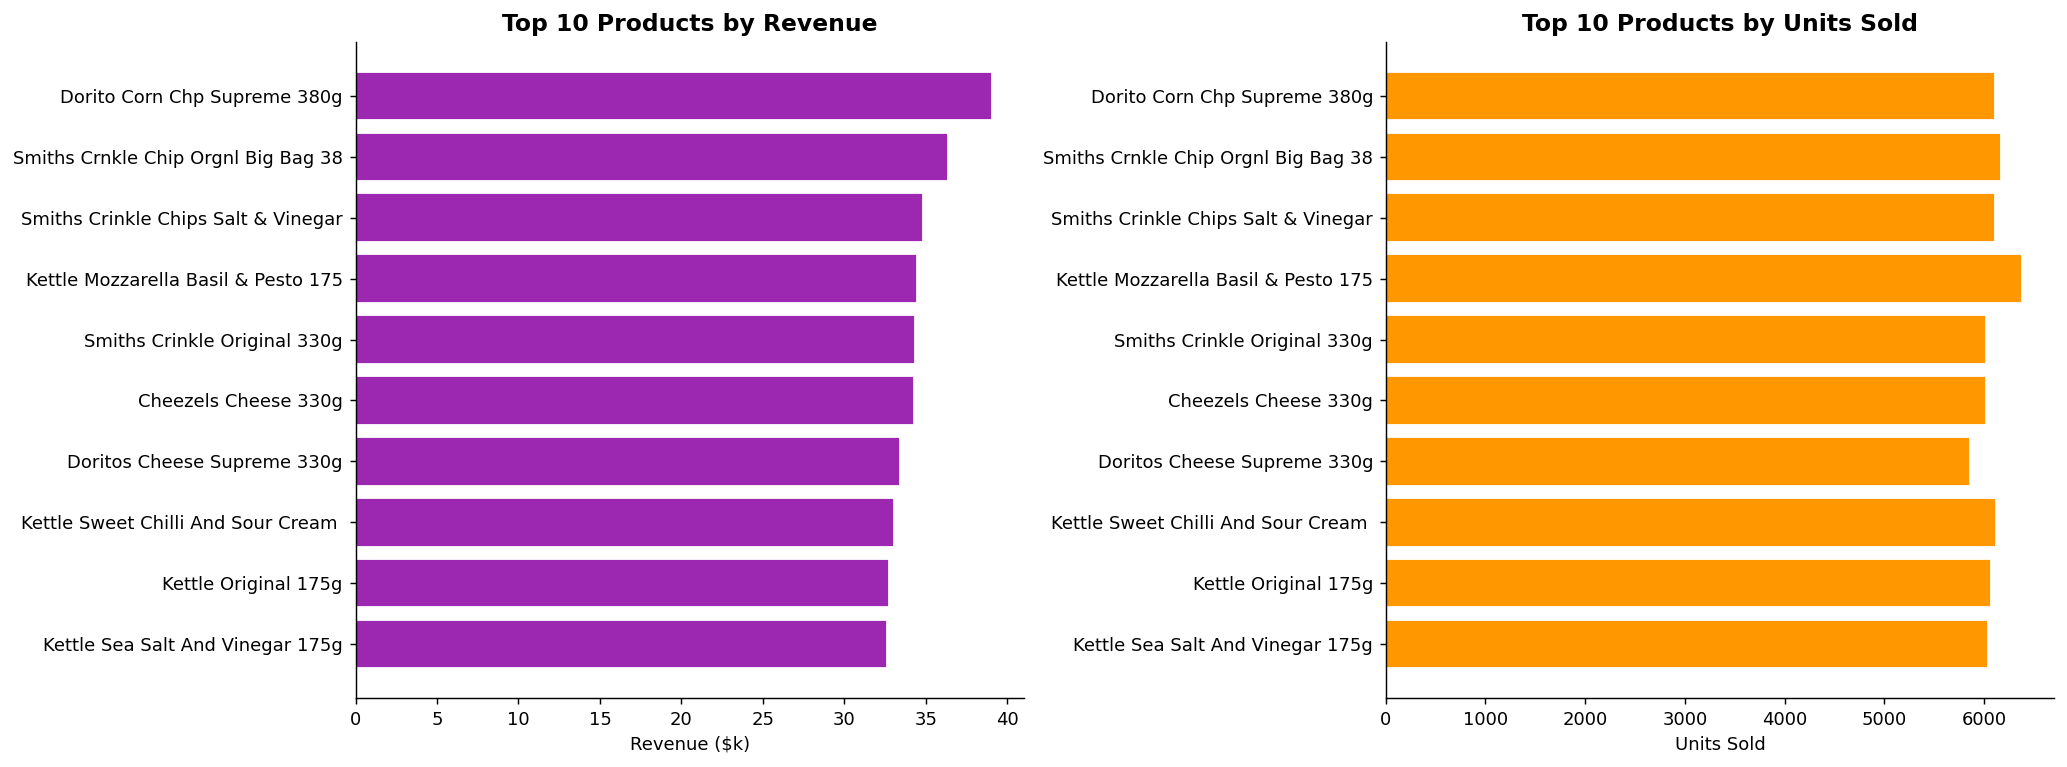

,Product,Revenue,Units_Sold,Avg_Price,Txns
0,Dorito Corn Chp Supreme 380g,39052.0,6109,6.368285,3183
1,Smiths Crnkle Chip Orgnl Big Bag 38,36367.6,6164,5.900000,3233
2,Smiths Crinkle Chips Salt & Vinegar,34804.2,6106,5.700000,3197
3,Kettle Mozzarella Basil & Pesto 175,34457.4,6381,5.400000,3304
4,Smiths Crinkle Original 330g,34302.6,6018,5.700000,3142
5,Cheezels Cheese 330g,34296.9,6017,5.700000,3149
6,Doritos Cheese Supreme 330g,33390.6,5858,5.700000,3052
7,Kettle Sweet Chilli And Sour Cream,33031.8,6120,5.398988,3200
8,Kettle Original 175g,32740.2,6064,5.399145,3159
9,Kettle Sea Salt And Vinegar 175g,32589.0,6035,5.400000,3173


In [15]:
top_prod = df.groupby('PROD_NAME').agg(
    Revenue   =('TOT_SALES','sum'),
    Units_Sold=('PROD_QTY','sum'),
    Avg_Price =('UNIT_PRICE','mean'),
    Txns      =('TXN_ID','count')
).sort_values('Revenue', ascending=False).head(10).reset_index()

top_prod['SHORT_NAME'] = top_prod['PROD_NAME'].str.replace(r'\s+', ' ', regex=True).str.strip().str[:35]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_prod['SHORT_NAME'][::-1], top_prod['Revenue'][::-1]/1000, color=PALETTE[3], edgecolor='white')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Revenue ($k)')

axes[1].barh(top_prod['SHORT_NAME'][::-1], top_prod['Units_Sold'][::-1], color=PALETTE[4], edgecolor='white')
axes[1].set_title('Top 10 Products by Units Sold')
axes[1].set_xlabel('Units Sold')

plt.tight_layout()
plt.show()

display(top_prod[['SHORT_NAME','Revenue','Units_Sold','Avg_Price','Txns']].rename(columns={'SHORT_NAME':'Product'}))

### 5.3 Pack Size Deep Dive

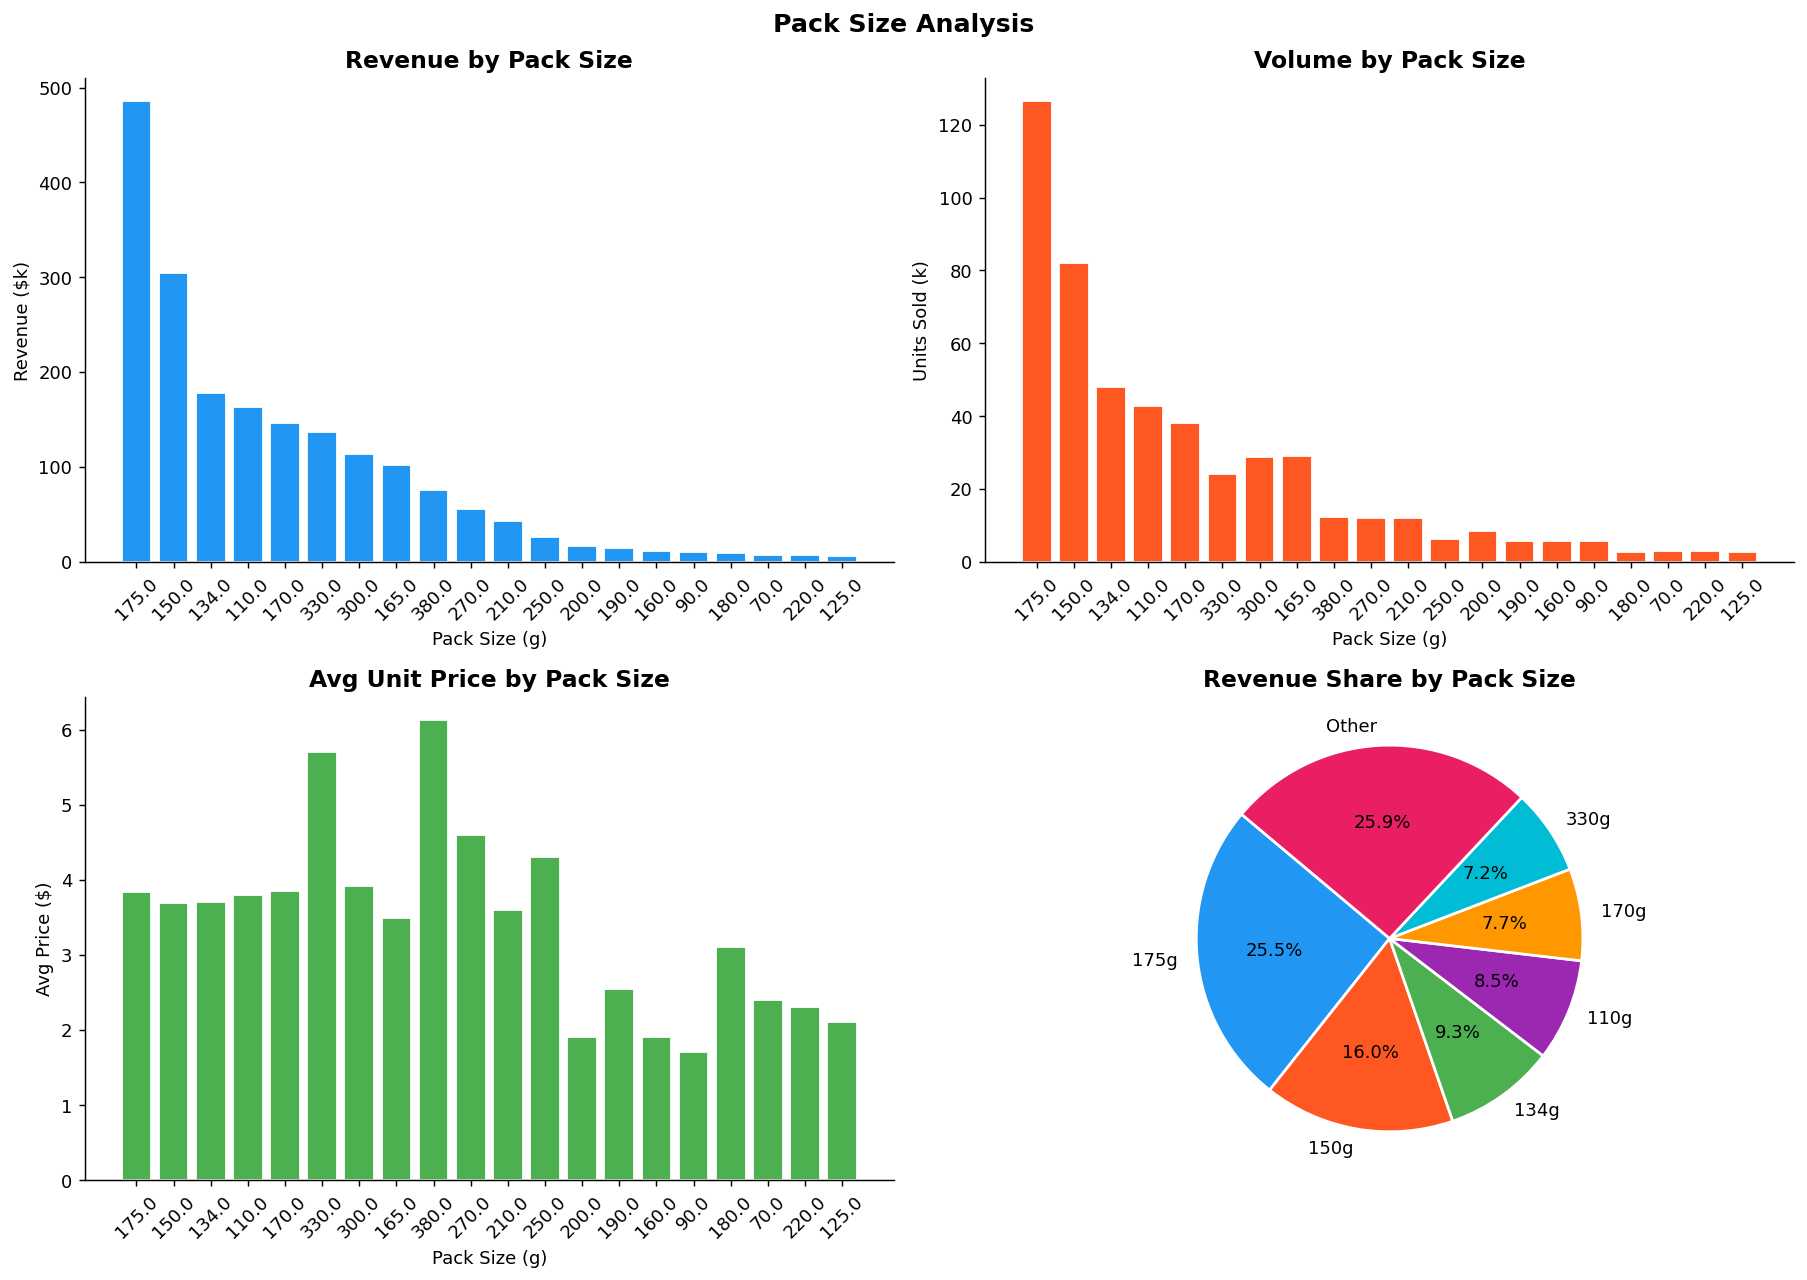

In [16]:
pack = df.groupby('PACK_SIZE').agg(
    Revenue   =('TOT_SALES','sum'),
    Units_Sold=('PROD_QTY','sum'),
    Avg_Price =('UNIT_PRICE','mean'),
    Txns      =('TXN_ID','count')
).dropna().sort_values('Revenue', ascending=False).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue by pack
axes[0,0].bar(pack['PACK_SIZE'].astype(str), pack['Revenue']/1000, color=PALETTE[0], edgecolor='white')
axes[0,0].set_title('Revenue by Pack Size')
axes[0,0].set_xlabel('Pack Size (g)')
axes[0,0].set_ylabel('Revenue ($k)')
axes[0,0].tick_params(axis='x', rotation=45)

# Volume by pack
axes[0,1].bar(pack['PACK_SIZE'].astype(str), pack['Units_Sold']/1000, color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('Volume by Pack Size')
axes[0,1].set_xlabel('Pack Size (g)')
axes[0,1].set_ylabel('Units Sold (k)')
axes[0,1].tick_params(axis='x', rotation=45)

# Avg price by pack
axes[1,0].bar(pack['PACK_SIZE'].astype(str), pack['Avg_Price'], color=PALETTE[2], edgecolor='white')
axes[1,0].set_title('Avg Unit Price by Pack Size')
axes[1,0].set_xlabel('Pack Size (g)')
axes[1,0].set_ylabel('Avg Price ($)')
axes[1,0].tick_params(axis='x', rotation=45)

# Revenue share pie
top_packs = pack.head(6)
other_rev = pack.iloc[6:]['Revenue'].sum()
pie_labels = [f'{int(p)}g' for p in top_packs['PACK_SIZE']] + ['Other']
pie_vals   = list(top_packs['Revenue']) + [other_rev]
axes[1,1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
              colors=PALETTE[:7], startangle=140,
              wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1,1].set_title('Revenue Share by Pack Size')

plt.suptitle('Pack Size Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Brand Loyalty — Repeat Purchase Rate

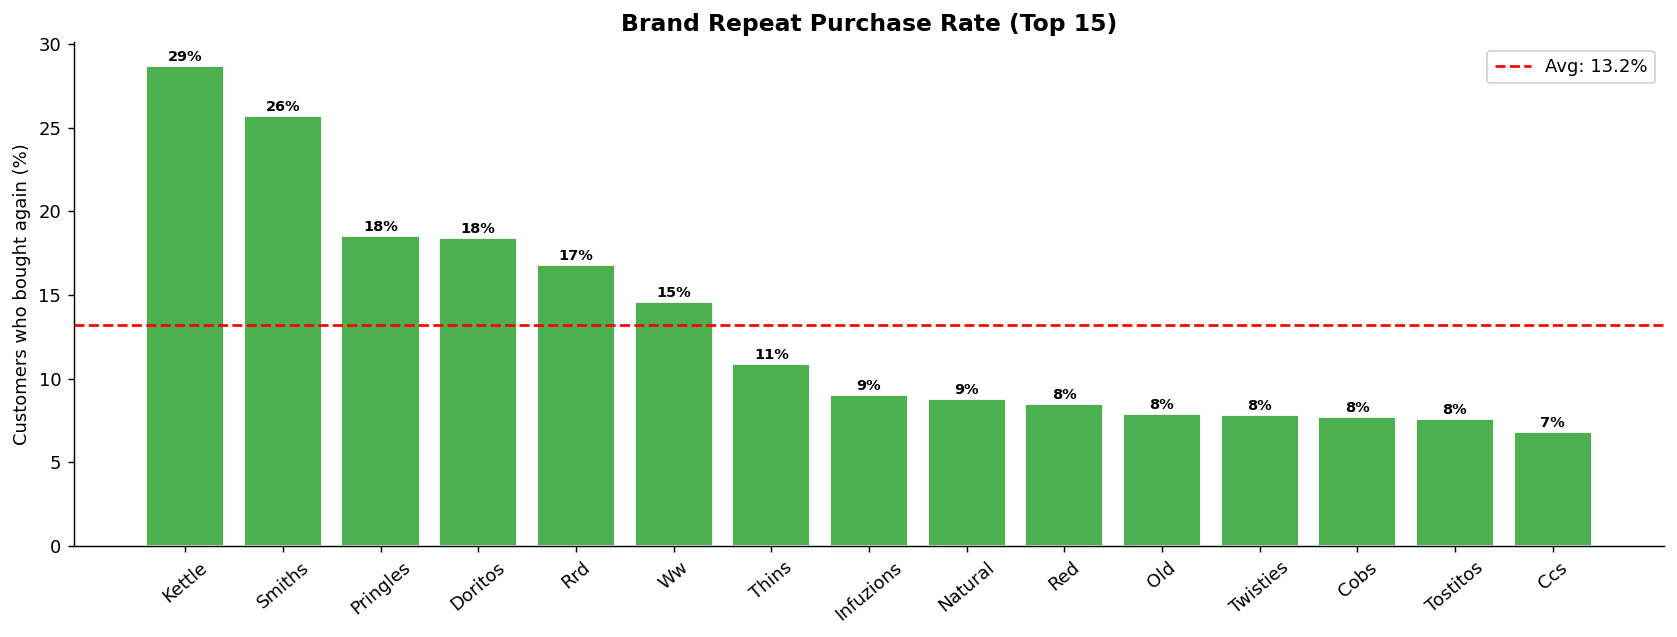

In [17]:
brand_cust = df.groupby(['LYLTY_CARD_NBR','BRAND']).size().reset_index(name='PURCHASES')
repeat     = brand_cust[brand_cust['PURCHASES'] > 1].groupby('BRAND').size()
total_cust = brand_cust.groupby('BRAND').size()
loyalty    = (repeat / total_cust * 100).dropna().sort_values(ascending=False).head(15).round(1)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(loyalty.index, loyalty.values, color=PALETTE[2], edgecolor='white')
ax.axhline(loyalty.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Avg: {loyalty.mean():.1f}%')
ax.set_title('Brand Repeat Purchase Rate (Top 15)')
ax.set_ylabel('Customers who bought again (%)')
ax.tick_params(axis='x', rotation=40)
ax.legend(fontsize=10)
for bar, val in zip(bars, loyalty.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Customer Analysis

### 6.1 Life Stage & Premium Tier Distribution

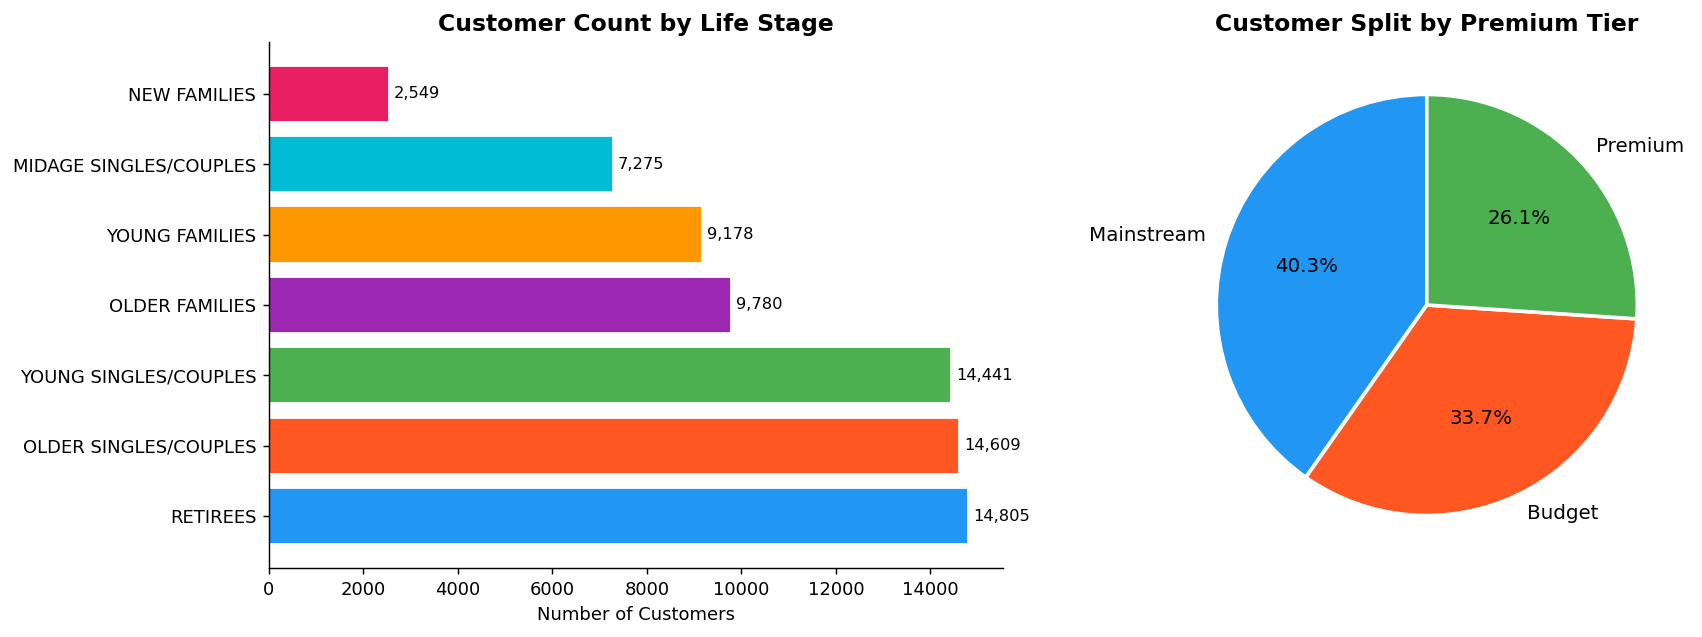

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ls_counts = beh['LIFESTAGE'].value_counts()
axes[0].barh(ls_counts.index, ls_counts.values, color=PALETTE[:len(ls_counts)], edgecolor='white')
axes[0].set_title('Customer Count by Life Stage')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(ls_counts.values):
    axes[0].text(v+100, i, f'{v:,}', va='center', fontsize=9)

pc_counts = beh['PREMIUM_CUSTOMER'].value_counts()
axes[1].pie(pc_counts.values, labels=pc_counts.index, autopct='%1.1f%%',
            colors=PALETTE[:3], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':11})
axes[1].set_title('Customer Split by Premium Tier')

plt.tight_layout()
plt.show()

### 6.2 Revenue by Life Stage × Premium Tier

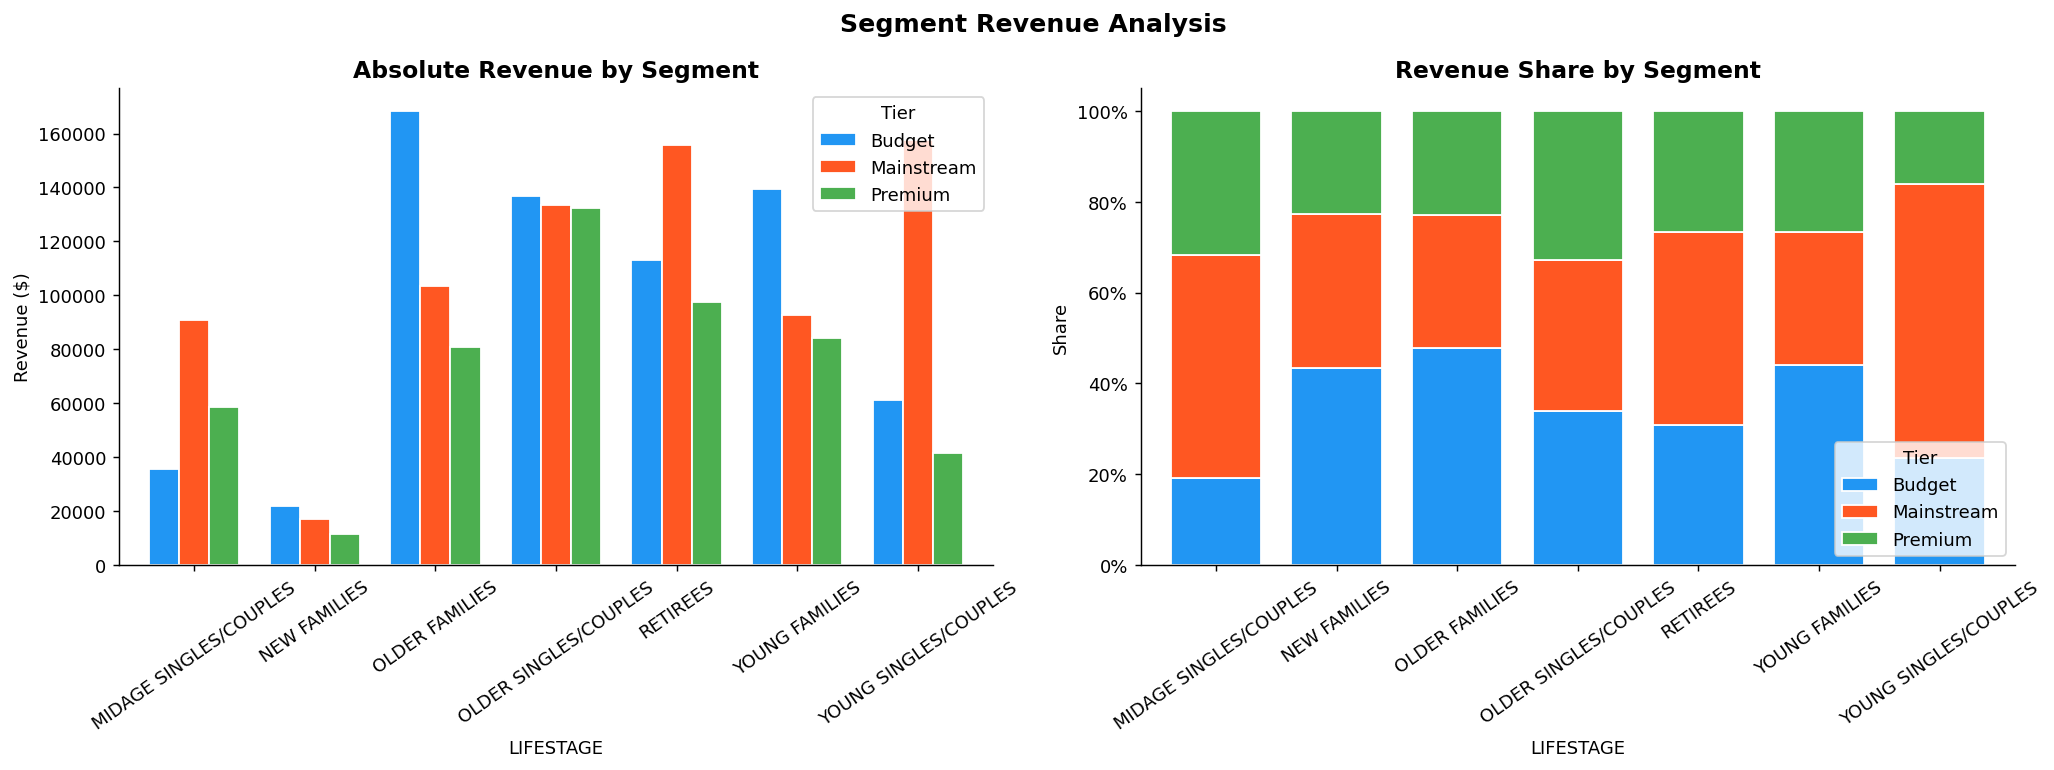

In [19]:
seg_rev = df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack(fill_value=0)
seg_pct = seg_rev.div(seg_rev.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_rev.plot(kind='bar', ax=axes[0], color=PALETTE[:3], edgecolor='white', width=0.75)
axes[0].set_title('Absolute Revenue by Segment')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Tier', loc='upper right')

seg_pct.plot(kind='bar', stacked=True, ax=axes[1], color=PALETTE[:3], edgecolor='white', width=0.75)
axes[1].set_title('Revenue Share by Segment')
axes[1].set_ylabel('Share')
axes[1].tick_params(axis='x', rotation=35)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(title='Tier', loc='lower right')

plt.suptitle('Segment Revenue Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Avg Basket & Quantity Heatmaps

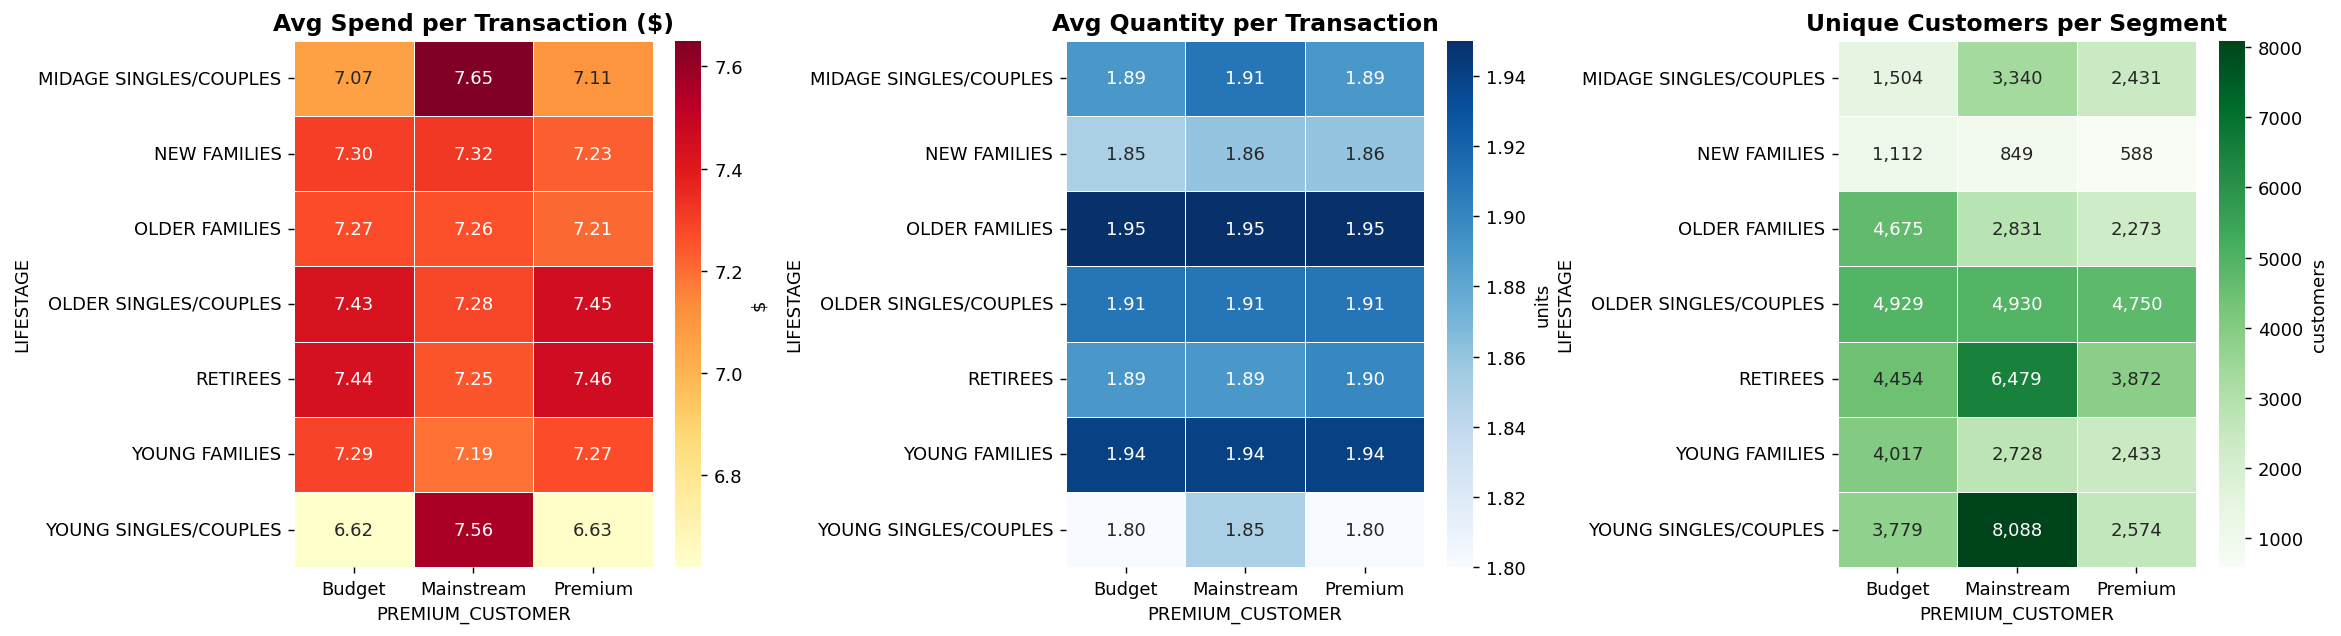

In [20]:
basket = df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg(
    Avg_Spend   =('TOT_SALES','mean'),
    Avg_Qty     =('PROD_QTY', 'mean'),
    Total_Rev   =('TOT_SALES','sum'),
    Num_Customers=('LYLTY_CARD_NBR','nunique')
).reset_index()

pivot_spend = basket.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='Avg_Spend').round(2)
pivot_qty   = basket.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='Avg_Qty').round(2)
pivot_cust  = basket.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='Num_Customers')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(pivot_spend, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label':'$'})
axes[0].set_title('Avg Spend per Transaction ($)')

sns.heatmap(pivot_qty, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'units'})
axes[1].set_title('Avg Quantity per Transaction')

sns.heatmap(pivot_cust, annot=True, fmt=',d', cmap='Greens', ax=axes[2],
            linewidths=0.5, cbar_kws={'label':'customers'})
axes[2].set_title('Unique Customers per Segment')

plt.tight_layout()
plt.show()

### 6.4 Customer Purchase Frequency

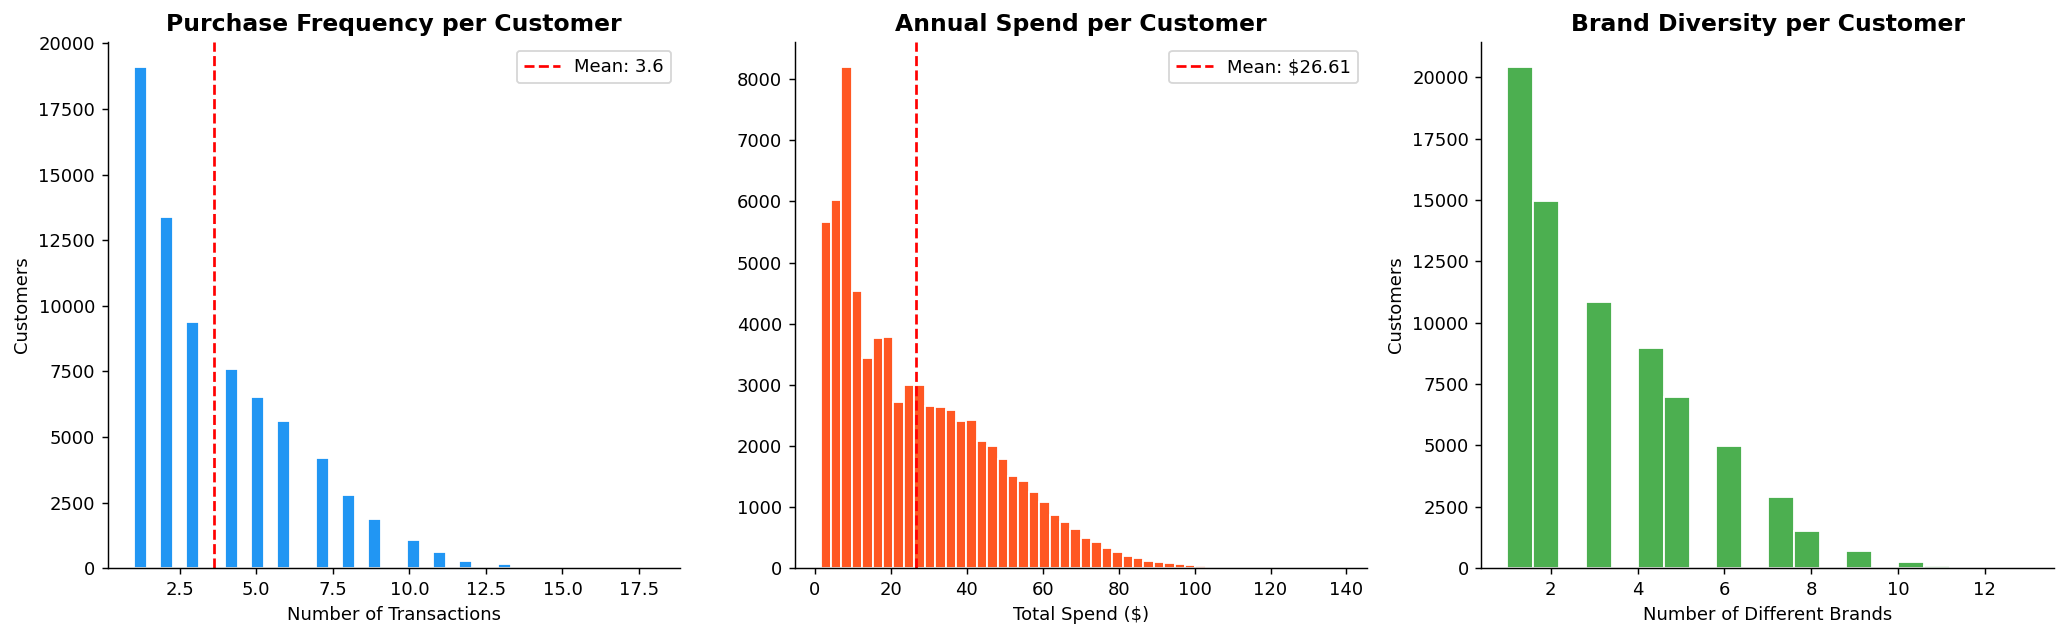

Avg transactions per customer : 3.62
Avg annual spend per customer : $26.61
Avg brands tried per customer : 3.11


In [21]:
cust_freq = df.groupby('LYLTY_CARD_NBR').agg(
    Num_Txns  =('TXN_ID',    'nunique'),
    Total_Spend=('TOT_SALES','sum'),
    Avg_Basket =('TOT_SALES','mean'),
    Num_Brands =('BRAND',    'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(cust_freq['Num_Txns'], bins=40, color=PALETTE[0], edgecolor='white')
axes[0].axvline(cust_freq['Num_Txns'].mean(), color='red', linestyle='--',
                label=f'Mean: {cust_freq["Num_Txns"].mean():.1f}')
axes[0].set_title('Purchase Frequency per Customer')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Customers')
axes[0].legend()

axes[1].hist(cust_freq['Total_Spend'].clip(upper=500), bins=50, color=PALETTE[1], edgecolor='white')
axes[1].axvline(cust_freq['Total_Spend'].mean(), color='red', linestyle='--',
                label=f'Mean: ${cust_freq["Total_Spend"].mean():.2f}')
axes[1].set_title('Annual Spend per Customer')
axes[1].set_xlabel('Total Spend ($)')
axes[1].legend()

axes[2].hist(cust_freq['Num_Brands'], bins=20, color=PALETTE[2], edgecolor='white')
axes[2].set_title('Brand Diversity per Customer')
axes[2].set_xlabel('Number of Different Brands')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()

print(f'Avg transactions per customer : {cust_freq["Num_Txns"].mean():.2f}')
print(f'Avg annual spend per customer : ${cust_freq["Total_Spend"].mean():.2f}')
print(f'Avg brands tried per customer : {cust_freq["Num_Brands"].mean():.2f}')

### 6.5 Top & Bottom 10% Customers (High Value vs Low Value)

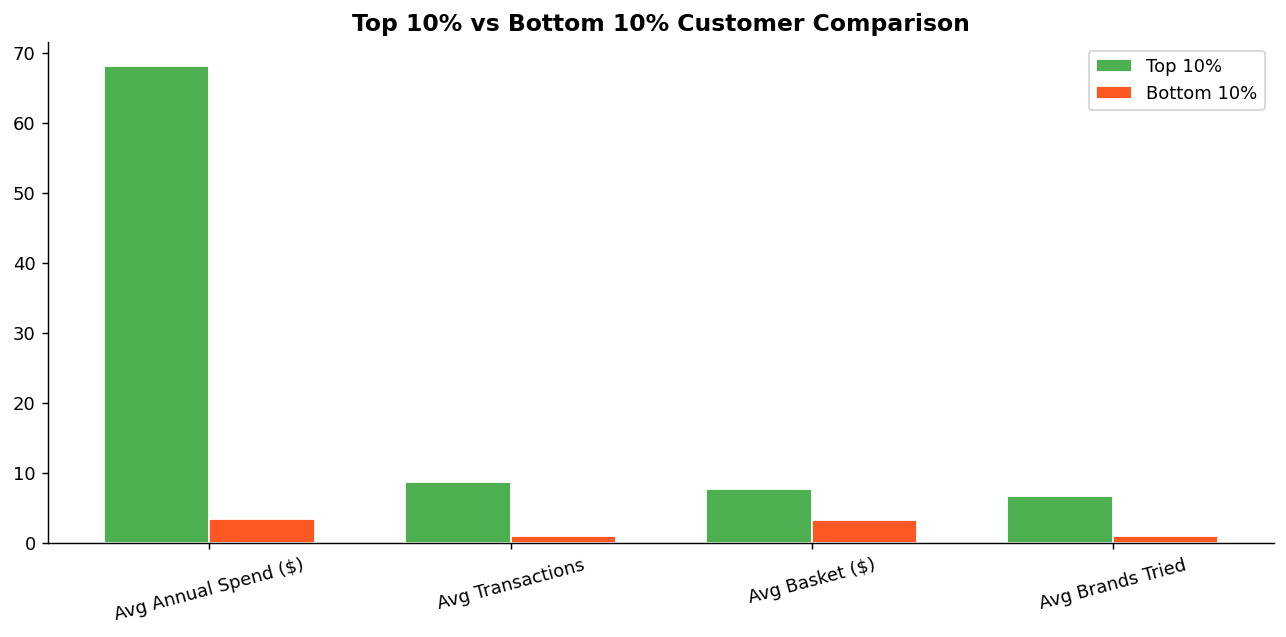

,Top 10% Customers,Bottom 10% Customers
Metric,,
Avg Annual Spend ($),68.20,3.42
Avg Transactions,8.76,1.04
Avg Basket ($),7.82,3.33
Avg Brands Tried,6.71,1.04


In [22]:
top10pct    = cust_freq.nlargest(int(len(cust_freq)*0.1), 'Total_Spend')
bottom10pct = cust_freq.nsmallest(int(len(cust_freq)*0.1), 'Total_Spend')

compare = pd.DataFrame({
    'Metric'          : ['Avg Annual Spend ($)', 'Avg Transactions', 'Avg Basket ($)', 'Avg Brands Tried'],
    'Top 10% Customers'   : [
        top10pct['Total_Spend'].mean(),
        top10pct['Num_Txns'].mean(),
        top10pct['Avg_Basket'].mean(),
        top10pct['Num_Brands'].mean()
    ],
    'Bottom 10% Customers': [
        bottom10pct['Total_Spend'].mean(),
        bottom10pct['Num_Txns'].mean(),
        bottom10pct['Avg_Basket'].mean(),
        bottom10pct['Num_Brands'].mean()
    ]
})
compare = compare.set_index('Metric').round(2)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare))
width = 0.35
bars1 = ax.bar(x - width/2, compare['Top 10% Customers'],    width, label='Top 10%',    color=PALETTE[2], edgecolor='white')
bars2 = ax.bar(x + width/2, compare['Bottom 10% Customers'], width, label='Bottom 10%', color=PALETTE[1], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=15)
ax.set_title('Top 10% vs Bottom 10% Customer Comparison')
ax.legend()

plt.tight_layout()
plt.show()
display(compare)

---
## 7. Store Analysis

### 7.1 Store Performance Distribution

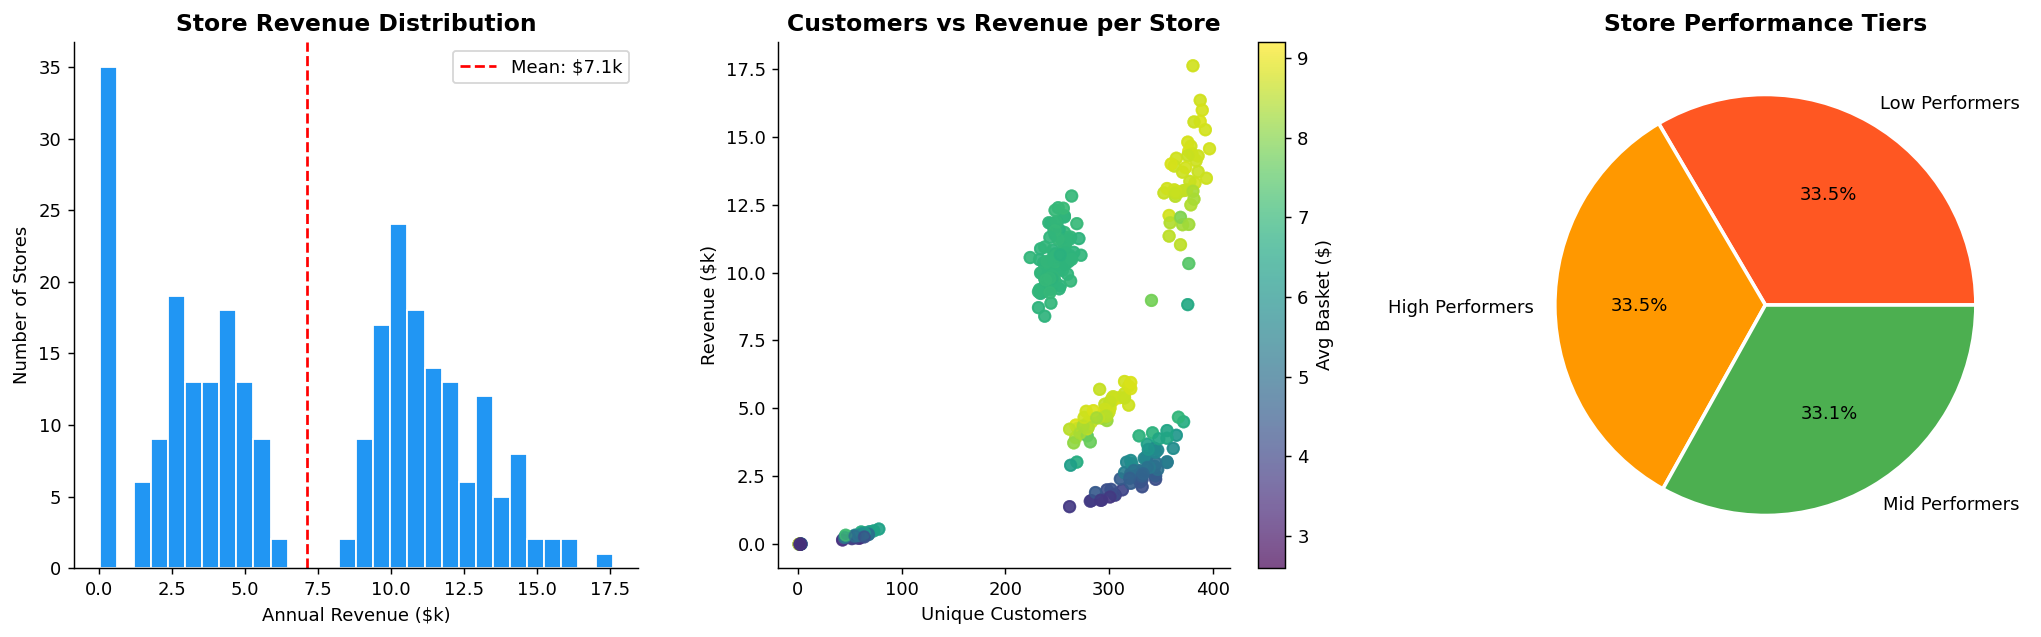


Top 10 stores by revenue:


,STORE_NBR,Revenue,Transactions,Customers,Avg_Basket
0,226,17605.45,2008,381,8.715569
1,88,16333.25,1857,388,8.720368
2,165,15973.75,1806,390,8.781611
3,40,15559.50,1756,388,8.820578
4,237,15539.50,1773,382,8.705602
5,58,15251.45,1727,393,8.750115
6,199,14797.00,1671,376,8.771191
7,4,14647.65,1667,379,8.729231
8,203,14551.60,1650,397,8.760747
9,26,14469.30,1632,377,8.822744


In [23]:
store = df.groupby('STORE_NBR').agg(
    Revenue     =('TOT_SALES',      'sum'),
    Transactions=('TXN_ID',         'nunique'),
    Customers   =('LYLTY_CARD_NBR', 'nunique'),
    Avg_Basket  =('TOT_SALES',      'mean'),
    Avg_Qty     =('PROD_QTY',       'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(store['Revenue']/1000, bins=30, color=PALETTE[0], edgecolor='white')
axes[0].axvline(store['Revenue'].mean()/1000, color='red', linestyle='--',
                label=f'Mean: ${store["Revenue"].mean()/1000:.1f}k')
axes[0].set_title('Store Revenue Distribution')
axes[0].set_xlabel('Annual Revenue ($k)')
axes[0].set_ylabel('Number of Stores')
axes[0].legend()

axes[1].scatter(store['Customers'], store['Revenue']/1000,
                c=store['Avg_Basket'], cmap='viridis', s=40, alpha=0.7)
sc = axes[1].scatter(store['Customers'], store['Revenue']/1000,
                     c=store['Avg_Basket'], cmap='viridis', s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='Avg Basket ($)')
axes[1].set_title('Customers vs Revenue per Store')
axes[1].set_xlabel('Unique Customers')
axes[1].set_ylabel('Revenue ($k)')

# Revenue percentile bands
store['Tier'] = pd.qcut(store['Revenue'], q=3, labels=['Low','Mid','High'])
tier_counts = store['Tier'].value_counts()
axes[2].pie(tier_counts.values, labels=[f'{l} Performers' for l in tier_counts.index],
            autopct='%1.1f%%', colors=[PALETTE[1],PALETTE[4],PALETTE[2]],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('Store Performance Tiers')

plt.tight_layout()
plt.show()

print('\nTop 10 stores by revenue:')
display(store.sort_values('Revenue', ascending=False).head(10)[['STORE_NBR','Revenue','Transactions','Customers','Avg_Basket']].reset_index(drop=True))

### 7.2 Store Monthly Revenue Trend (Top 5 Stores)

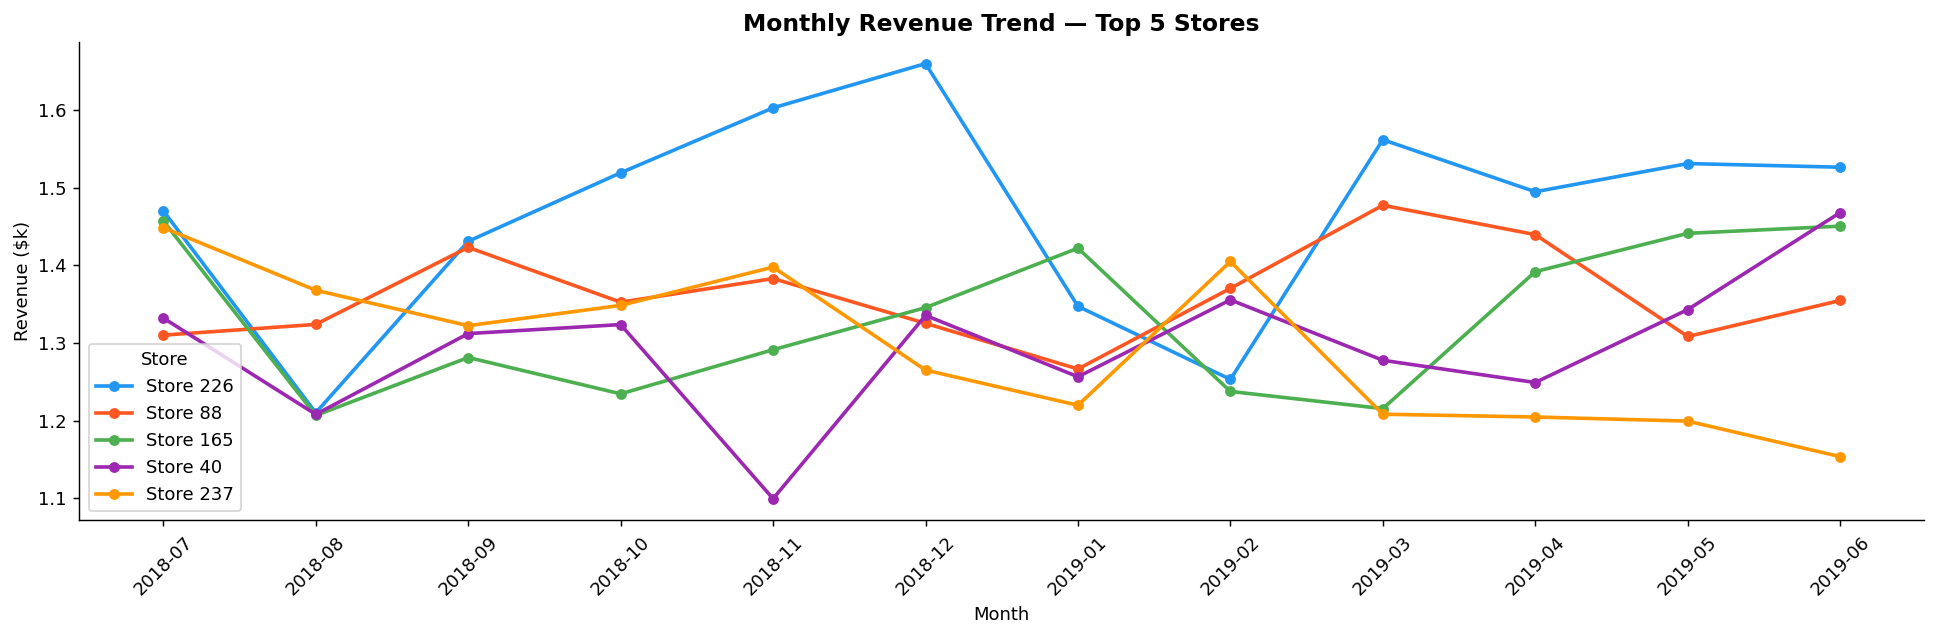

In [24]:
top5_stores = store.sort_values('Revenue', ascending=False).head(5)['STORE_NBR'].tolist()

store_monthly = df[df['STORE_NBR'].isin(top5_stores)].groupby(['STORE_NBR','MONTH'])['TOT_SALES'].sum().reset_index()
store_monthly['MONTH_STR'] = store_monthly['MONTH'].astype(str)

fig, ax = plt.subplots(figsize=(15, 5))
for i, s in enumerate(top5_stores):
    subset = store_monthly[store_monthly['STORE_NBR']==s]
    ax.plot(subset['MONTH_STR'], subset['TOT_SALES']/1000, marker='o',
            linewidth=2, markersize=5, label=f'Store {s}', color=PALETTE[i])

ax.set_title('Monthly Revenue Trend — Top 5 Stores')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($k)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Store')
plt.tight_layout()
plt.show()

---
## 8. Customer Segmentation (RFM Analysis)

### 8.1 Build RFM Table

In [25]:
SNAPSHOT = df['DATE'].max() + pd.Timedelta(days=1)

rfm = df.groupby('LYLTY_CARD_NBR').agg(
    Recency   =('DATE',    lambda x: (SNAPSHOT - x.max()).days),
    Frequency =('TXN_ID',  'nunique'),
    Monetary  =('TOT_SALES','sum')
).reset_index()

# Score each metric 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment labels
def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4: return '🏆 Champions'
    elif r >= 4 and f >= 3:          return '💛 Loyal Customers'
    elif r >= 3 and f <= 2:          return '🌱 Potential Loyalists'
    elif r <= 2 and f >= 3:          return '⚠️ At Risk'
    elif r <= 2 and f <= 2:          return '❌ Lost'
    else:                            return '😴 Needs Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print('RFM Segment Distribution:')
print(rfm['Segment'].value_counts())
print()
display(rfm.head(10))

RFM Segment Distribution:
Segment
❌ Lost                   18816
🏆 Champions              16885
🌱 Potential Loyalists    10239
⚠️ At Risk               10152
😴 Needs Attention         9835
💛 Loyal Customers         6709
Name: count, dtype: int64



,LYLTY_CARD_NBR,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
0,1000,257,1,6.0,1,1,1,3,❌ Lost
1,1002,288,1,2.7,1,1,1,3,❌ Lost
2,1003,115,2,6.6,2,2,1,5,❌ Lost
3,1004,241,1,1.9,1,1,1,3,❌ Lost
4,1005,185,1,2.8,2,1,1,4,❌ Lost
5,1007,208,2,6.5,1,2,1,4,❌ Lost
6,1009,223,1,5.7,1,1,1,3,❌ Lost
7,1010,199,2,13.9,1,2,2,5,❌ Lost
8,1011,194,4,18.0,1,3,3,7,⚠️ At Risk
9,1012,12,2,10.3,5,2,2,9,🌱 Potential Loyalists


### 8.2 RFM Segment Visualisation

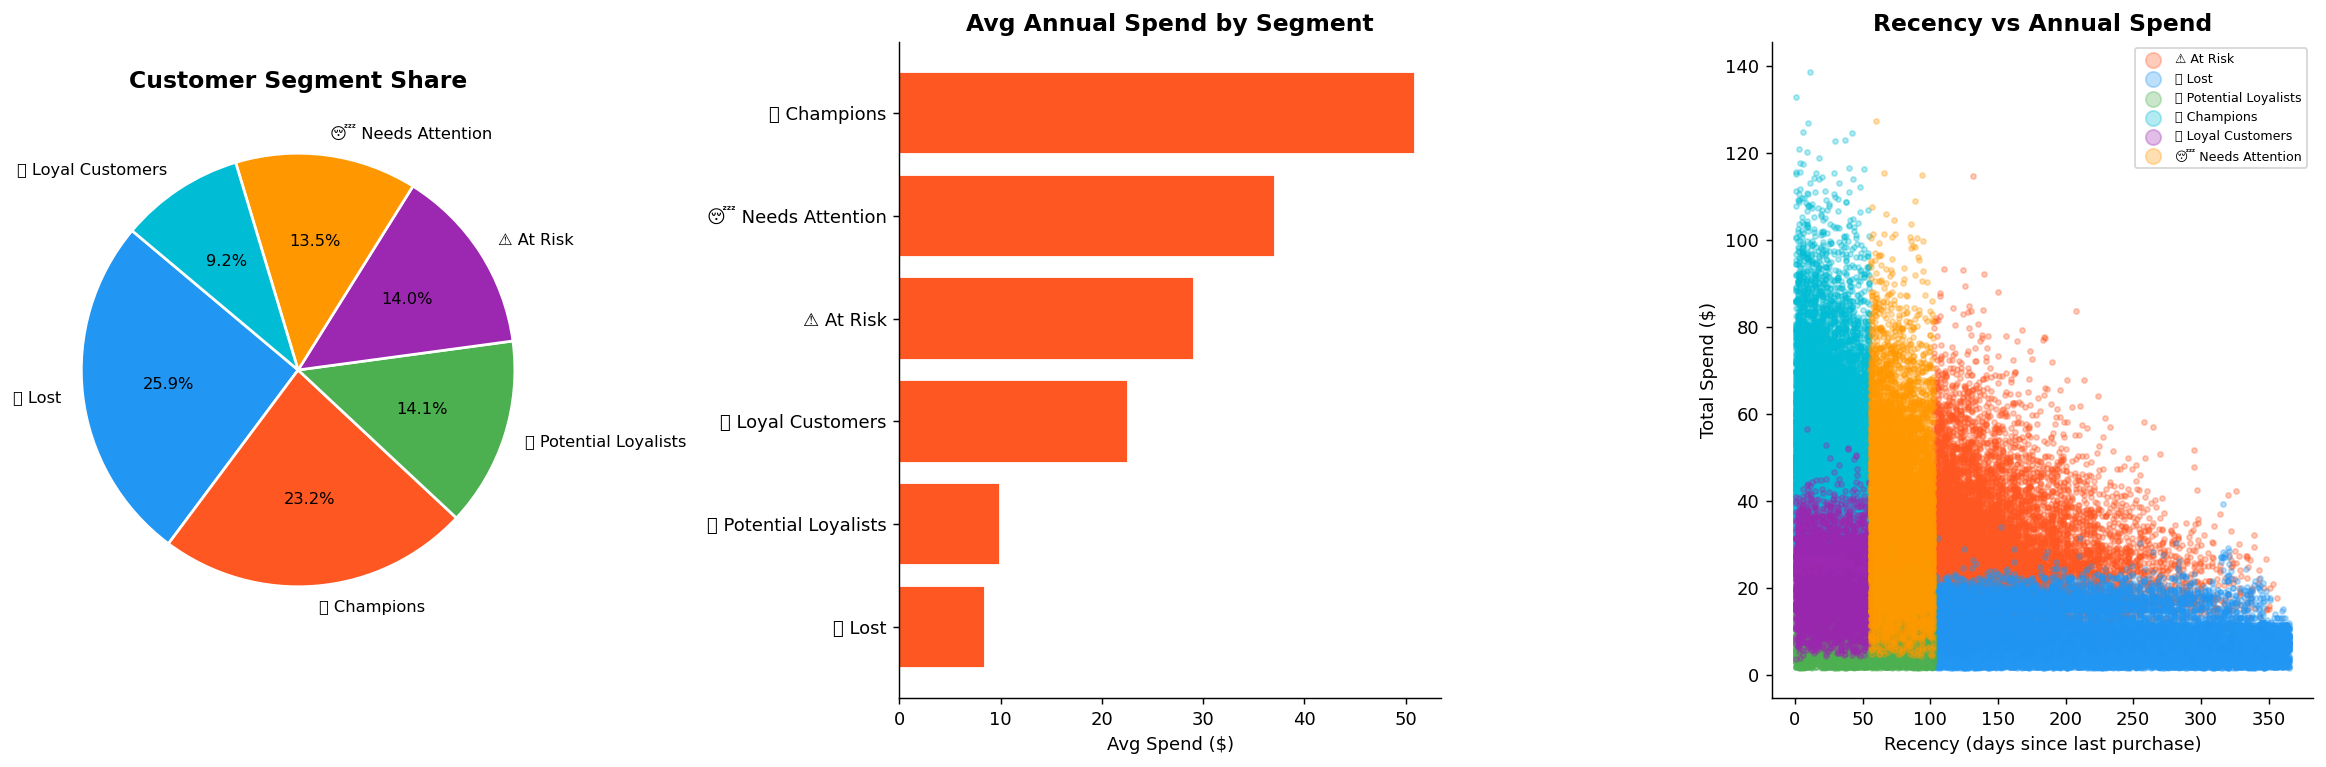

In [26]:
seg_counts = rfm['Segment'].value_counts()
seg_stats  = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie — segment share
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=PALETTE[:len(seg_counts)], startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5},
            textprops={'fontsize':9})
axes[0].set_title('Customer Segment Share')

# Avg spend by segment
seg_stats_sorted = seg_stats.sort_values('Monetary', ascending=True)
axes[1].barh(seg_stats_sorted.index, seg_stats_sorted['Monetary'], color=PALETTE[1], edgecolor='white')
axes[1].set_title('Avg Annual Spend by Segment')
axes[1].set_xlabel('Avg Spend ($)')

# Recency vs Monetary scatter
seg_colors = {s: PALETTE[i] for i, s in enumerate(rfm['Segment'].unique())}
for seg, grp in rfm.groupby('Segment'):
    axes[2].scatter(grp['Recency'], grp['Monetary'], s=8, alpha=0.3,
                    label=seg, color=seg_colors[seg])
axes[2].set_title('Recency vs Annual Spend')
axes[2].set_xlabel('Recency (days since last purchase)')
axes[2].set_ylabel('Total Spend ($)')
axes[2].legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()

### 8.3 RFM Segment × Life Stage Cross-Tab

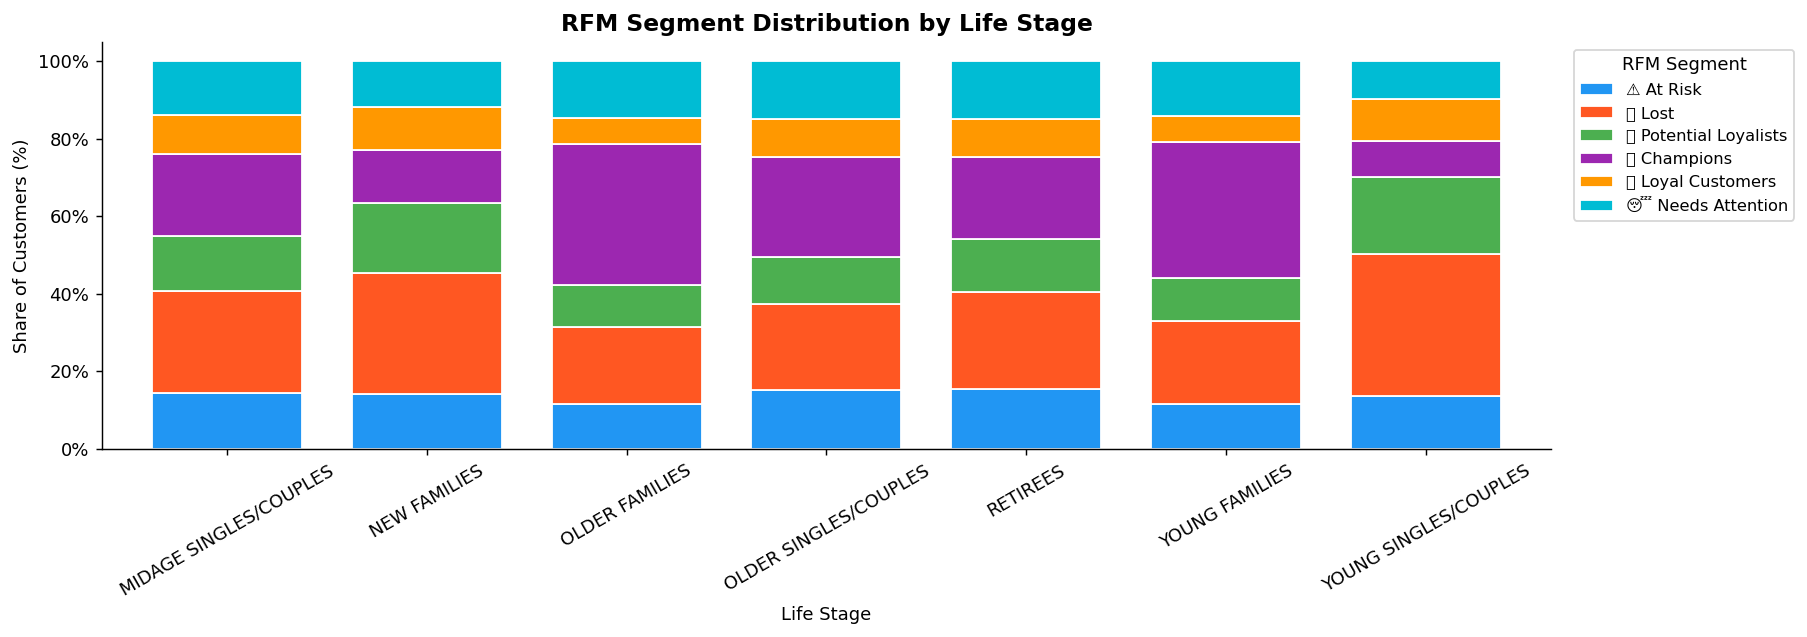

In [27]:
rfm_ls = rfm.merge(beh[['LYLTY_CARD_NBR','LIFESTAGE','PREMIUM_CUSTOMER']], on='LYLTY_CARD_NBR', how='left')

cross_ls = pd.crosstab(rfm_ls['LIFESTAGE'], rfm_ls['Segment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 5))
cross_ls.plot(kind='bar', stacked=True, ax=ax, color=PALETTE[:6], edgecolor='white', width=0.75)
ax.set_title('RFM Segment Distribution by Life Stage')
ax.set_ylabel('Share of Customers (%)')
ax.set_xlabel('Life Stage')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='RFM Segment', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Segment Deep Dive — Preferred Brands & Products

In [28]:
# Top brand per Life Stage segment
seg_brand = df.groupby(['LIFESTAGE','BRAND'])['TOT_SALES'].sum().reset_index()
top_brand_per_seg = seg_brand.loc[seg_brand.groupby('LIFESTAGE')['TOT_SALES'].idxmax()]

# Top brand per Premium tier
tier_brand = df.groupby(['PREMIUM_CUSTOMER','BRAND'])['TOT_SALES'].sum().reset_index()
top_brand_per_tier = tier_brand.loc[tier_brand.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].idxmax()]

print('=== Top Brand per Life Stage ===')
display(top_brand_per_seg[['LIFESTAGE','BRAND','TOT_SALES']].rename(columns={'TOT_SALES':'Revenue ($)'}).reset_index(drop=True))

print('\n=== Top Brand per Premium Tier ===')
display(top_brand_per_tier[['PREMIUM_CUSTOMER','BRAND','TOT_SALES']].rename(columns={'TOT_SALES':'Revenue ($)'}).reset_index(drop=True))

=== Top Brand per Life Stage ===


,LIFESTAGE,BRAND,Revenue ($)
0,MIDAGE SINGLES/COUPLES,Kettle,38358.2
1,NEW FAMILIES,Kettle,10846.2
2,OLDER FAMILIES,Kettle,65984.0
3,OLDER SINGLES/COUPLES,Kettle,83862.6
4,RETIREES,Kettle,76914.8
5,YOUNG FAMILIES,Kettle,60033.0
6,YOUNG SINGLES/COUPLES,Kettle,54241.0



=== Top Brand per Premium Tier ===


,PREMIUM_CUSTOMER,BRAND,Revenue ($)
0,Budget,Kettle,134407.8
1,Mainstream,Kettle,154477.0
2,Premium,Kettle,101355.0


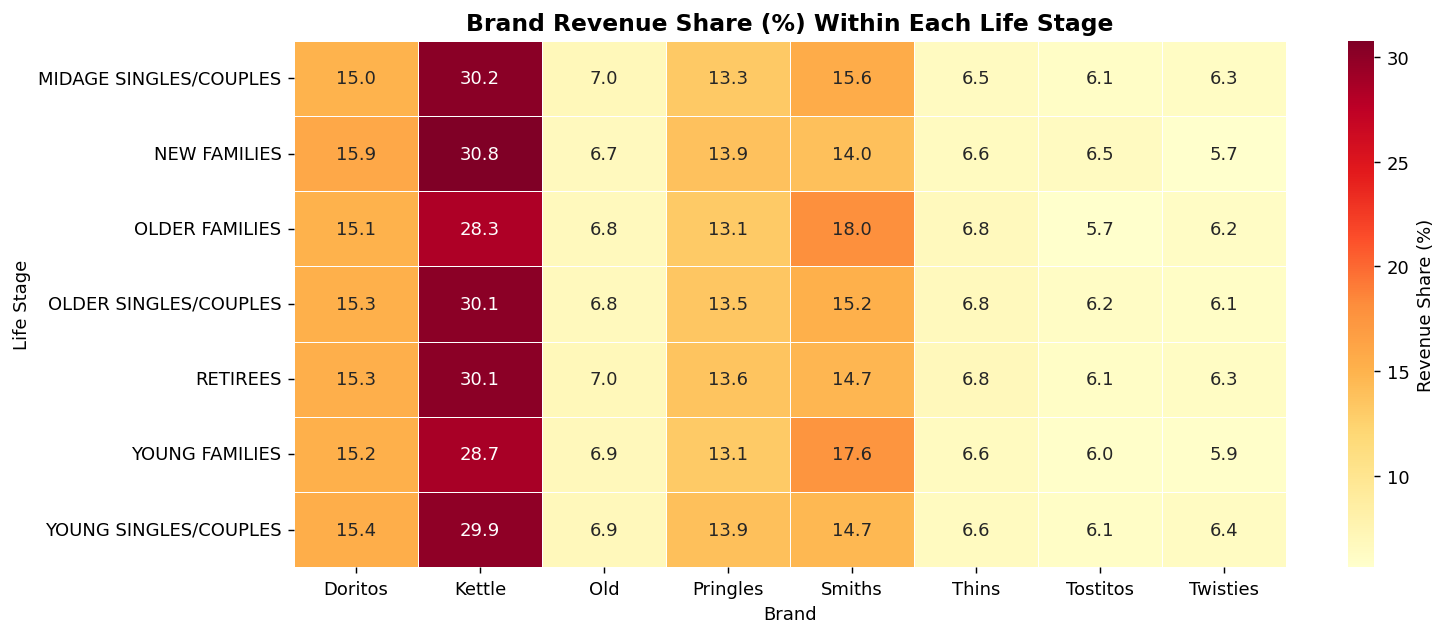

In [29]:
# Heatmap of top brands across segments
top8_brands = df.groupby('BRAND')['TOT_SALES'].sum().nlargest(8).index
brand_seg_heat = df[df['BRAND'].isin(top8_brands)].groupby(['LIFESTAGE','BRAND'])['TOT_SALES'].sum().unstack(fill_value=0)
brand_seg_norm = brand_seg_heat.div(brand_seg_heat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(brand_seg_norm, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Revenue Share (%)'})
ax.set_title('Brand Revenue Share (%) Within Each Life Stage', fontweight='bold', fontsize=13)
ax.set_xlabel('Brand')
ax.set_ylabel('Life Stage')
plt.tight_layout()
plt.show()

---
## 10. Key Findings & Business Recommendations

### 📊 Summary Dashboard

In [30]:
print('=' * 55)
print('         QVI RETAIL ANALYTICS — SUMMARY')
print('=' * 55)
print(f'  Total Revenue        : ${df["TOT_SALES"].sum():>12,.0f}')
print(f'  Total Transactions   : {df["TXN_ID"].nunique():>12,}')
print(f'  Unique Customers     : {df["LYLTY_CARD_NBR"].nunique():>12,}')
print(f'  Unique Stores        : {df["STORE_NBR"].nunique():>12}')
print(f'  Avg Basket Size      : ${df["TOT_SALES"].mean():>12.2f}')
print(f'  Top Brand            : {brand.iloc[0]["BRAND"]:>12}')
print(f'  Peak Month           : {monthly.loc[monthly["Revenue"].idxmax(), "MONTH_STR"]:>12}')
print(f'  Champions (RFM)      : {(rfm["Segment"]=="🏆 Champions").sum():>12,} customers')
print(f'  At Risk (RFM)        : {(rfm["Segment"]=="⚠️ At Risk").sum():>12,} customers')
print('=' * 55)

         QVI RETAIL ANALYTICS — SUMMARY
  Total Revenue        : $   1,933,115
  Total Transactions   :      263,125
  Unique Customers     :       72,636
  Unique Stores        :          272
  Avg Basket Size      : $        7.30
  Top Brand            :       Kettle
  Peak Month           :      2018-12
  Champions (RFM)      :       16,885 customers
  At Risk (RFM)        :       10,152 customers


### 📋 Findings & Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Older Families & Retirees** generate the highest absolute revenue | Run targeted promotions: bulk deals, loyalty rewards, family packs |
| 2 | **Mainstream Young Singles/Couples** have the highest transaction frequency | Launch a subscription or stamp-card loyalty programme for high-frequency buyers |
| 3 | **Kettle, Smiths & Pringles** dominate revenue and repeat purchases | Guarantee shelf presence; introduce cross-sell bundles with dips and drinks |
| 4 | **175g pack** leads revenue; **330g** has the highest unit price | Promote 330g packs in meal-deal bundles to drive margin uplift |
| 5 | **Weekend transactions** are higher in value than weekday | Run weekend-specific promotions to capitalise on higher-spending behaviour |
| 6 | **~15–20% of customers** are At Risk or Lost per RFM analysis | Re-engagement campaign via loyalty card email with personalised discount vouchers |
| 7 | **Champions** (top RFM) represent a small but highly valuable cohort | Protect with VIP programme — early access, exclusive deals, reward tiers |
| 8 | **Q2 (Oct–Dec)** shows the highest quarterly revenue | Increase stock levels and staff in Q2; plan promotional calendar around peak |

---

